# Projet ML: Prédiction du CO2 par habitant à partir du profil socio-économique d'un pays

**Objectif du projet** : comprendre comment le profil socio-économique d'un pays (développement, mode de vie, structure de production) permet de prédire ses émissions de CO2 par habitant (`co2_per_capita`).

**Dataset** : *Global Climate & CO2 Anomalies (1990-2024)*, 30 pays, 35 ans, 54 variables (climat, énergie, socio-économie). Source : Kaggle.

**Plan du notebook** :
1. Chargement des données
2. Exploration: comprendre la structure du dataset et les relations entre variables
3. Choix de la variable cible
4. Preprocessing (features, lags, split train/test)

**Partie 1 : différences entre pays**
- Test sur des pays jamais vus (validation croisée « un pays de côté »)

**Partie 2 : évolution dans le temps**
5. Modélisation (régression linéaire vs Random Forest)
6. Optimisation des hyperparamètres (GridSearchCV avec validation temporelle)
7. Diagnostic du modèle optimisé (courbes d'apprentissage, analyse des erreurs)
8. Amélioration du modèle : prédire la variation depuis la dernière année connue
9. Essai : réseau de neurones récurrent (LSTM)
10. Ajout des variables politiques

## 1. Chargement des données

In [238]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

In [239]:
df = pd.read_csv("global_climate_co2_anomalies.csv")   # chemin relatif : fichier à la racine du projet

df.head()

,country,iso_code,year,month,continent,income_group,latitude,longitude,latitude_band,climate_zone,...,forest_cover_pct,industrial_share_gdp,agriculture_share_gdp,vehicle_ownership,radiative_forcing,temp_change_from_co2,climate_risk_score,warming_category,renewable_transition_stage,emission_intensity_level
0,Argentina,ARG,1990,1,South America,Upper Middle,-34.0,-64.0,Temperate,Temperate,...,11,23,8,264.0,2.0,0.29,12.2,Normal,Low,Medium
1,Argentina,ARG,1990,2,South America,Upper Middle,-34.0,-64.0,Temperate,Temperate,...,11,23,8,260.0,2.0,0.29,18.5,Normal,Low,Medium
2,Argentina,ARG,1990,3,South America,Upper Middle,-34.0,-64.0,Temperate,Temperate,...,11,23,8,276.0,2.0,0.29,19.6,Normal,Low,Medium
3,Argentina,ARG,1990,4,South America,Upper Middle,-34.0,-64.0,Temperate,Temperate,...,11,23,8,278.0,2.0,0.29,15.1,Normal,Low,Medium
4,Argentina,ARG,1990,5,South America,Upper Middle,-34.0,-64.0,Temperate,Temperate,...,11,23,8,265.0,2.0,0.29,13.0,Normal,Low,Medium


**Problème découvert en explorant les données** : le CSV contient 12 600 lignes, mais avec 30 pays × 35 ans x12 mois/ans. Mais la plupart des variables (socio-économiques notamment) ne changent qu'une fois par an et sont **répétées à l'identique sur les 12 mois** de chaque année. Les garder créerait un risque de fuite de données (les 12 mois d'une même année pourraient se retrouver éclatés entre train et test). On réduit donc le dataset à une ligne par pays/année. Je choisis la 1er mois de chaque année

In [240]:
# Garder une seule ligne par pays/année au lieu de 12 (voir explication ci-dessus)
df_annual = df.drop_duplicates(subset=['country','year'], keep='first')

In [241]:
df_annual.head()

,country,iso_code,year,month,continent,income_group,latitude,longitude,latitude_band,climate_zone,...,forest_cover_pct,industrial_share_gdp,agriculture_share_gdp,vehicle_ownership,radiative_forcing,temp_change_from_co2,climate_risk_score,warming_category,renewable_transition_stage,emission_intensity_level
0,Argentina,ARG,1990,1,South America,Upper Middle,-34.0,-64.0,Temperate,Temperate,...,11,23,8,264.0,2.000,0.29,12.2,Normal,Low,Medium
12,Argentina,ARG,1991,1,South America,Upper Middle,-34.0,-64.0,Temperate,Temperate,...,11,23,8,276.0,2.059,0.27,17.7,Normal,Low,Medium
24,Argentina,ARG,1992,1,South America,Upper Middle,-34.0,-64.0,Temperate,Temperate,...,11,23,8,278.0,2.118,0.17,10.5,Normal,Low,Medium
36,Argentina,ARG,1993,1,South America,Upper Middle,-34.0,-64.0,Temperate,Temperate,...,11,23,8,284.0,2.177,0.17,9.3,Normal,Low,Medium
48,Argentina,ARG,1994,1,South America,Upper Middle,-34.0,-64.0,Temperate,Temperate,...,11,23,8,275.0,2.236,0.22,15.6,Normal,Low,Medium


In [242]:
# Vue d'ensemble des 54 colonnes disponibles
for col in df.columns:
    print(col)

country
iso_code
year
month
continent
income_group
latitude
longitude
latitude_band
climate_zone
temp_anomaly_global
temp_anomaly_land
temp_anomaly_ocean
temp_anomaly_arctic
temp_max
temp_min
co2_emissions
co2_per_capita
co2_per_gdp
cumulative_co2
co2_concentration_ppm
methane_emissions
nitrous_oxide
total_ghg
land_use_change_co2
sea_ice_extent_arctic
sea_ice_extent_antarc
sea_surface_temp_anom
nino34_index
ocean_heat_content
precipitation_anomaly
drought_index_pdsi
spi_3month
primary_energy_twh
share_renewables_pct
share_coal_pct
co2_per_kwh
electricity_demand_twh
renewable_capacity_gw
oil_production
population_millions
gdp_per_capita_usd
population_density
urbanization_rate
forest_cover_pct
industrial_share_gdp
agriculture_share_gdp
vehicle_ownership
radiative_forcing
temp_change_from_co2
climate_risk_score
warming_category
renewable_transition_stage
emission_intensity_level


## 2. Exploration, visualisation

### Population vs émissions totales de CO2

Première question : le volume total d'émissions d'un pays est-il simplement lié à sa taille démographique ?

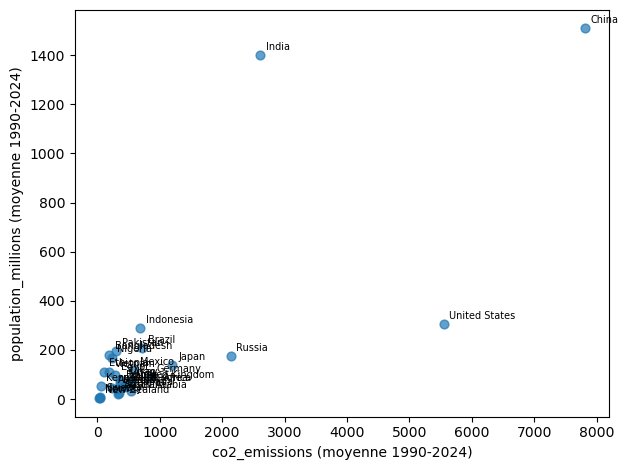

In [243]:
df_by_country = df_annual.groupby('country')[['population_millions','co2_per_capita','co2_emissions']].mean().reset_index()


plt.scatter(df_by_country['co2_emissions'], df_by_country['population_millions'], alpha=0.7, s=40)

for _, row in df_by_country.iterrows():
    plt.annotate(row['country'], (row['co2_emissions'], row['population_millions']),
                 fontsize=(7), xytext=(4,4), textcoords='offset points')

plt.xlabel('co2_emissions (moyenne 1990-2024)')
plt.ylabel('population_millions (moyenne 1990-2024)')
plt.tight_layout()
plt.show()

**Constat** : relation clairement positive — plus un pays est peuplé, plus ses émissions totales sont élevées (Chine et Inde très à l'écart des autres). Logique mathématiquement : `co2_emissions = population × co2_per_capita`, et la population varie sur une bien plus grande échelle (~500x entre le plus petit et le plus grand pays) que le CO2 par habitant (~40x) — c'est donc elle qui domine le total, quasiment par construction.

### Qu'en est-il de `co2_per_capita` (CO2 par habitant) ?

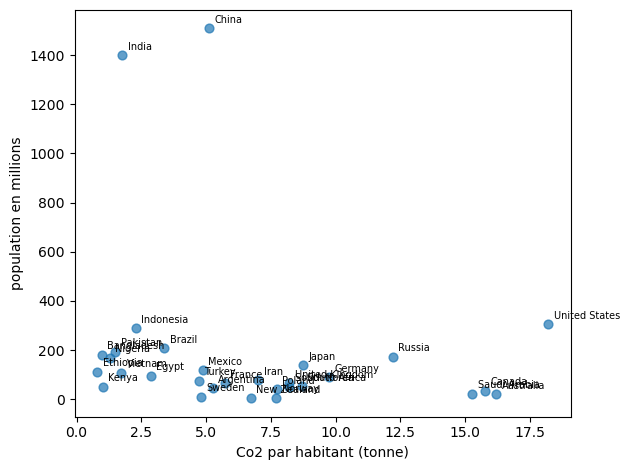

In [244]:
# Un point = un pays : moyenne sur les 35 ans
df_by_country = df_annual.groupby('country')[['population_millions','co2_per_capita']].mean().reset_index()

plt.scatter(df_by_country['co2_per_capita'], df_by_country['population_millions'], alpha=0.7, s=40)

for _, row in df_by_country.iterrows():
    plt.annotate(row['country'], (row['co2_per_capita'],row['population_millions']), fontsize=7, xytext=(4,4), textcoords='offset points')

plt.xlabel('Co2 par habitant (tonne)')
plt.ylabel('population en millions')
plt.tight_layout()
plt.show()

**Constat** : ici, plus de relation nette avec la population — l'Inde (très peuplée) a un `co2_per_capita` faible, alors que des pays peu peuplés comme l'Australie ou le Canada ont un `co2_per_capita` très élevé. Ça confirme que `co2_per_capita` raconte une histoire différente de `co2_emissions` : plutôt liée au développement/mode de vie qu'à la taille du pays.

**Question soulevée** : est-ce que `co2_per_capita` est une simple division `co2_emissions / population_millions`, ou une variable calculée différemment (empreinte carbone individuelle) ? Vérifions.

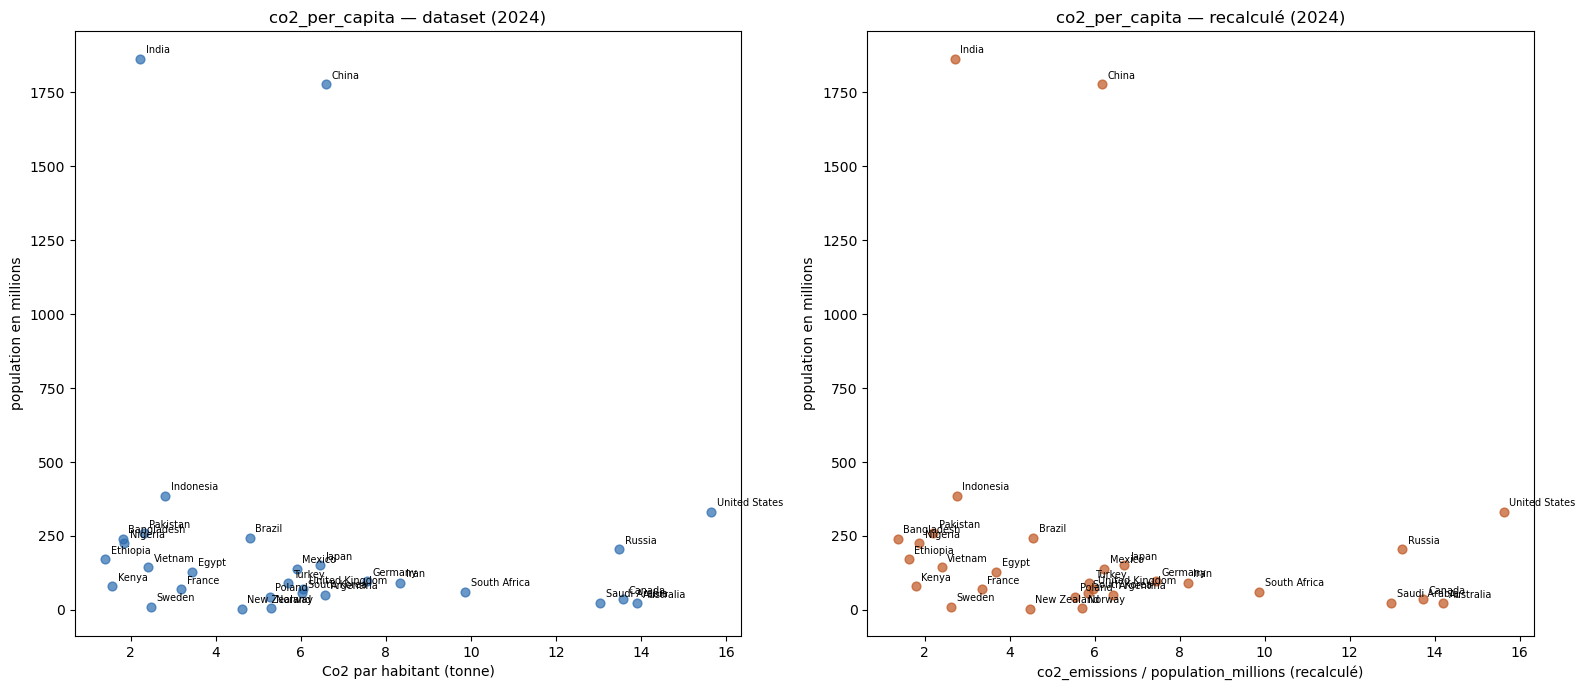

Écart absolu moyen: 0.19218796544860492
Écart absolu max: 0.47999195041455334
Corrélation: 0.9984291896658517


In [245]:
# Dernière année uniquement (2024), 1 point = 1 pays
df_last = df_annual[df_annual['year'] == df_annual['year'].max()].copy()
df_last['co2_pa_calc'] = df_last['co2_emissions'] / df_last['population_millions']

fig, axes = plt.subplots(1, 2, figsize=(16,7))

axes[0].scatter(df_last['co2_per_capita'], df_last['population_millions'], alpha=0.7, s=40, color='#2b6cb0')
for _, row in df_last.iterrows():
    axes[0].annotate(row['country'], (row['co2_per_capita'],row['population_millions']), fontsize=7, xytext=(4,4), textcoords='offset points')
axes[0].set_xlabel('Co2 par habitant (tonne)')
axes[0].set_ylabel('population en millions')
axes[0].set_title(f"co2_per_capita — dataset ({int(df_annual['year'].max())})")

axes[1].scatter(df_last['co2_pa_calc'], df_last['population_millions'],  alpha=0.7, s=40, color='#c05621')
for _, row in df_last.iterrows():
    axes[1].annotate(row['country'], (row['co2_pa_calc'], row['population_millions']), fontsize=7, xytext=(4,4), textcoords='offset points')
axes[1].set_xlabel('co2_emissions / population_millions (recalculé)')
axes[1].set_ylabel('population en millions')
axes[1].set_title(f"co2_per_capita — recalculé ({int(df_annual['year'].max())})")

plt.tight_layout()
plt.show()

diff = (df_last['co2_per_capita'] - df_last['co2_pa_calc']).abs()
print("Écart absolu moyen:", diff.mean())
print("Écart absolu max:", diff.max())
print("Corrélation:", df_last['co2_per_capita'].corr(df_last['co2_pa_calc']))

**Conclusion de cette vérification** : `co2_per_capita` et `co2_emissions / population_millions` sont extrêmement corrélées (>0.998) une fois agrégées par pays. `co2_per_capita` **est bien** dérivée de `co2_emissions`. Ce n'est donc pas une "empreinte carbone individuelle" indépendante : c'est la même information territoriale que `co2_emissions`, juste ramenée par habitant.

### Quelles variables socio-économiques sont liées à `co2_per_capita` et à `co2_emissions` ?

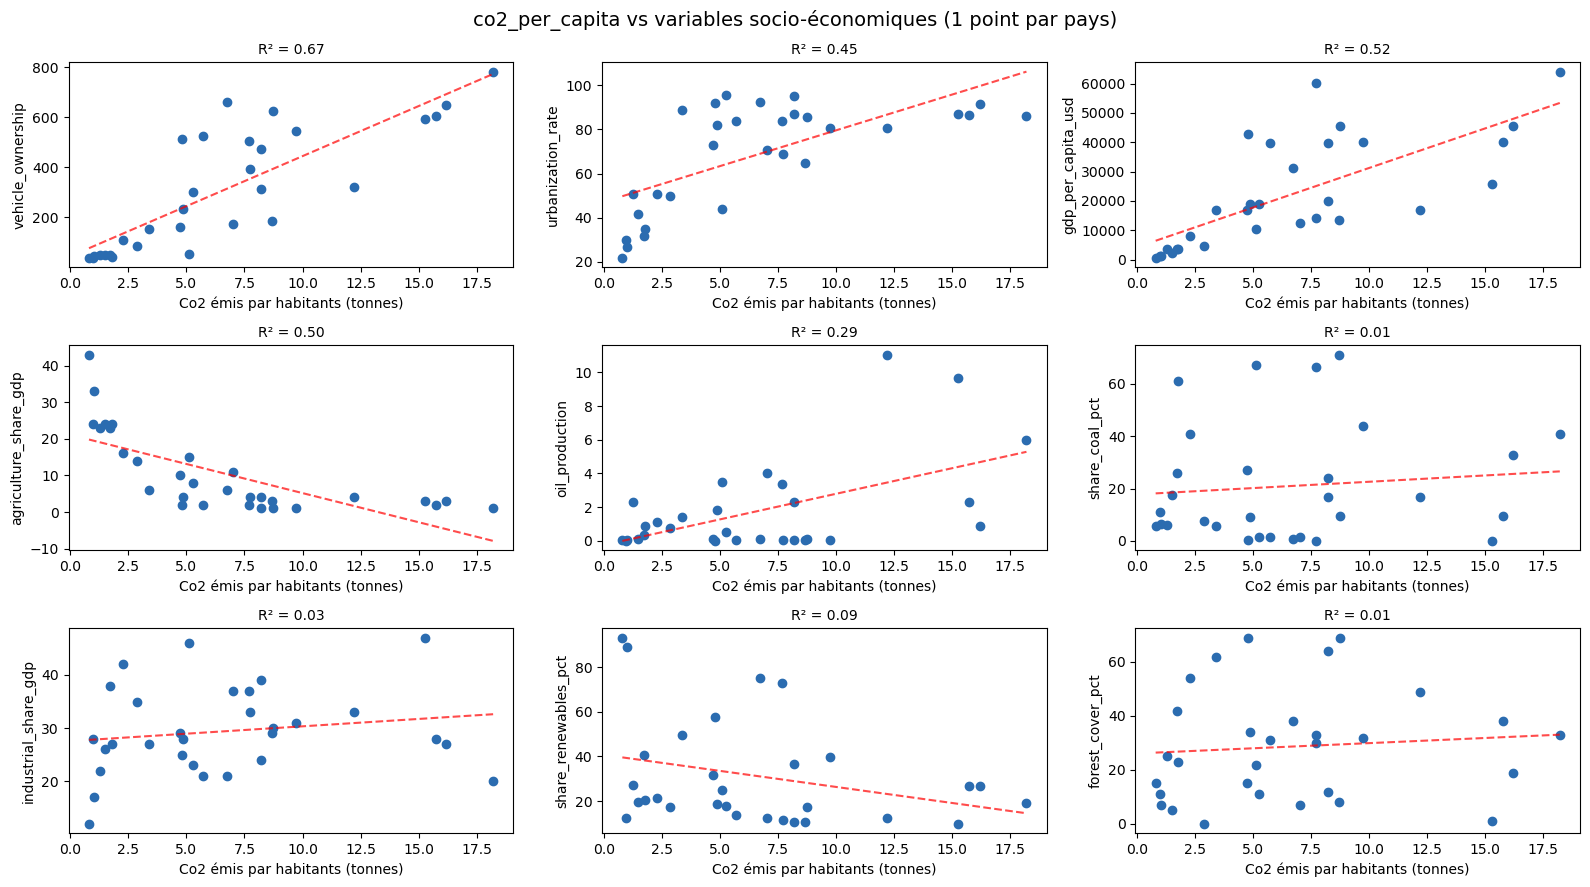

In [246]:
from scipy.stats import linregress

vars_to_plot = ['vehicle_ownership','urbanization_rate','gdp_per_capita_usd','agriculture_share_gdp',
                'oil_production','share_coal_pct','industrial_share_gdp','share_renewables_pct','forest_cover_pct']

df_by_country = df_annual.groupby('country')[vars_to_plot + ['co2_per_capita','co2_emissions']].mean().reset_index()

fig, axes = plt.subplots(3, 3, figsize=(16,9))
axes = axes.flatten()

for ax, var in zip(axes, vars_to_plot):
    ax.scatter(df_by_country['co2_per_capita'], df_by_country[var], color='#2b6cb0')
    ax.set_xlabel('Co2 émis par habitants (tonnes)')
    ax.set_ylabel(var)
    # Régression linéaire + R² (part des écarts entre pays expliquée par la droite, de 0 à 1)
    reg = linregress(df_by_country['co2_per_capita'], df_by_country[var])
    xs = np.linspace(df_by_country['co2_per_capita'].min(), df_by_country['co2_per_capita'].max(), 50)
    ax.plot(xs, reg.slope * xs + reg.intercept, 'r--', alpha=0.7)
    ax.set_title(f"R² = {reg.rvalue**2:.2f}", fontsize=10)

plt.suptitle("co2_per_capita vs variables socio-économiques (1 point par pays)", fontsize=14)
plt.tight_layout()

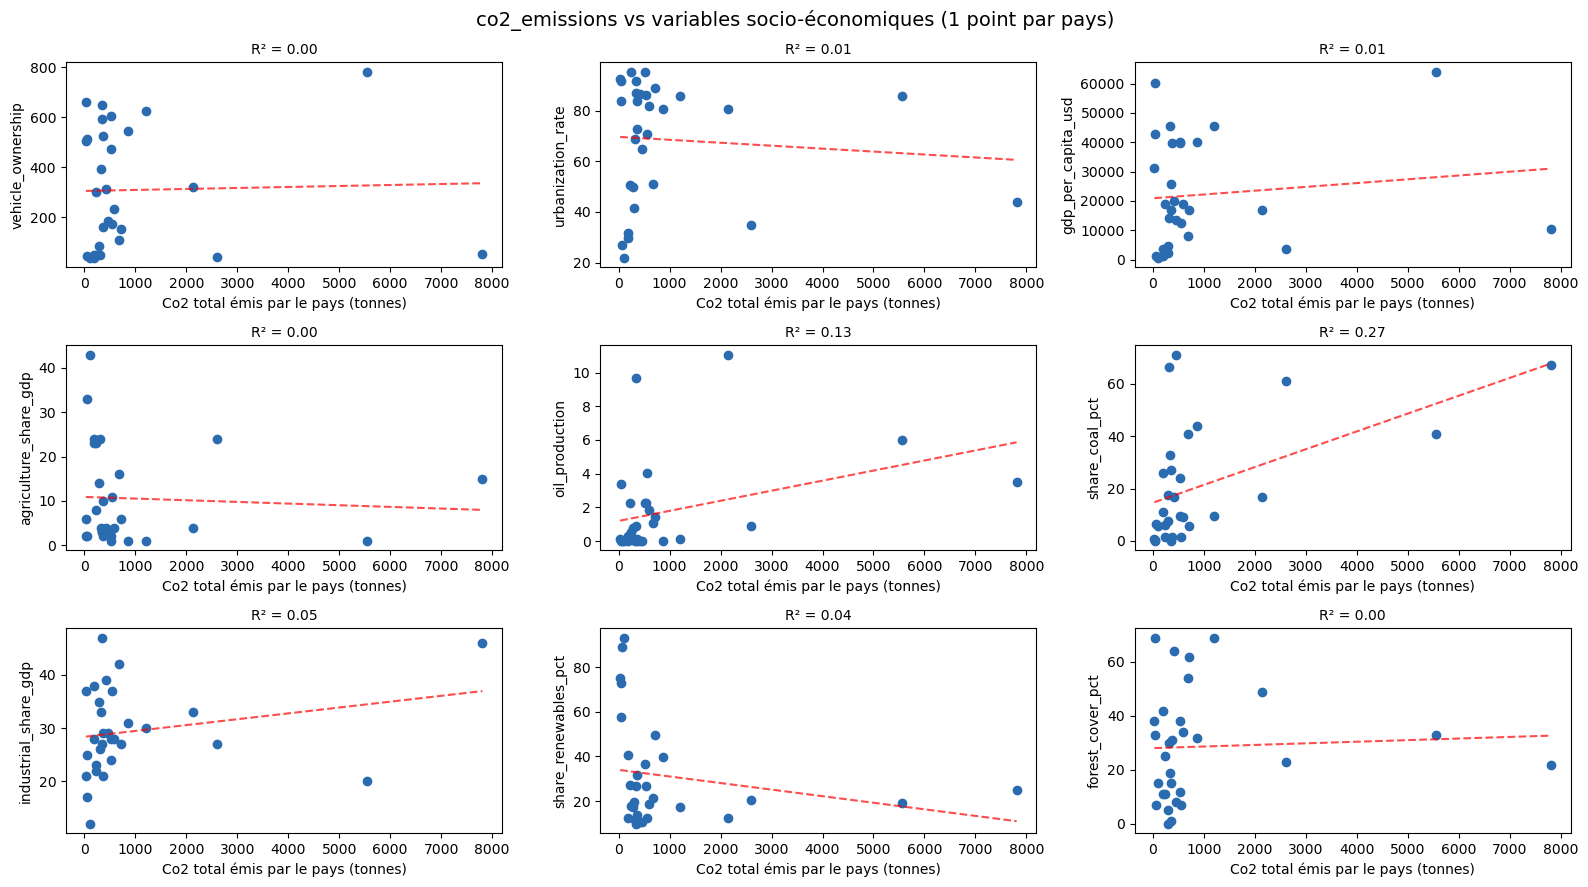

In [247]:
fig, axes = plt.subplots(3, 3, figsize=(16,9))
axes = axes.flatten()

for ax, var in zip(axes, vars_to_plot):
    ax.scatter(df_by_country['co2_emissions'], df_by_country[var], color='#2b6cb0')
    ax.set_xlabel('Co2 total émis par le pays (tonnes)')
    ax.set_ylabel(var)
    # Régression linéaire + R² (part des écarts entre pays expliquée par la droite, de 0 à 1)
    reg = linregress(df_by_country['co2_emissions'], df_by_country[var])
    xs = np.linspace(df_by_country['co2_emissions'].min(), df_by_country['co2_emissions'].max(), 50)
    ax.plot(xs, reg.slope * xs + reg.intercept, 'r--', alpha=0.7)
    ax.set_title(f"R² = {reg.rvalue**2:.2f}", fontsize=10)

plt.suptitle("co2_emissions vs variables socio-économiques (1 point par pays)", fontsize=14)
plt.tight_layout()

**Constat** : ces variables socio-économiques sont bien corrélées à `co2_per_capita`, mais beaucoup moins à `co2_emissions` (sauf `share_coal_pct` un peu) : le mode de vie/développement individuel se reflète dans le CO2 *par habitant*, pas dans le volume *total*, qui est dominé par l'effet de taille du pays (population).

In [248]:
y = df_annual['co2_per_capita']
moy_pays = df_annual.groupby('country')['co2_per_capita'].transform('mean')

var_totale = y.var(ddof=0)
var_entre  = moy_pays.var(ddof=0)          # différences entre pays
var_intra  = (y - moy_pays).var(ddof=0)    # évolution dans le temps d'un même pays

print(f"Entre pays : {var_entre/var_totale:.1%} | Intra-pays : {var_intra/var_totale:.1%}")

Entre pays : 96.9% | Intra-pays : 3.1%


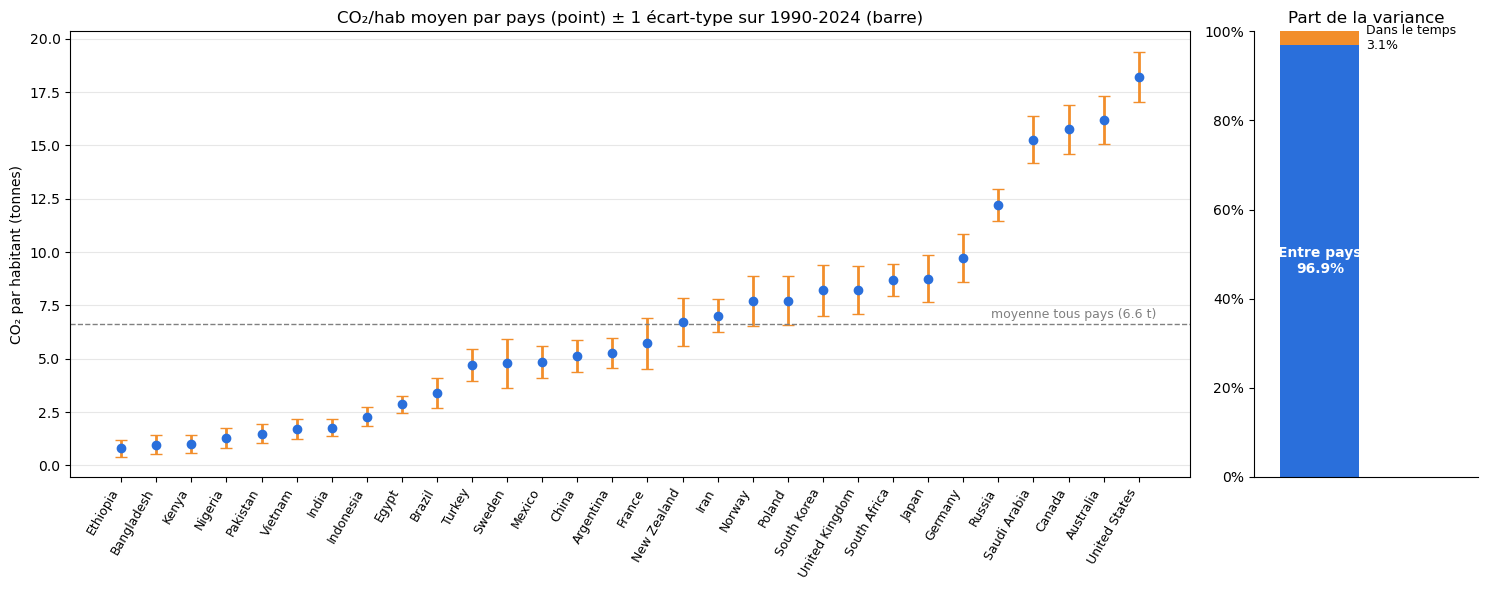

In [249]:
# Moyenne ± écart-type du CO2/hab de chaque pays (sur ses 35 années), pays triés par moyenne
stats_pays = df_annual.groupby('country')['co2_per_capita'].agg(['mean', 'std']).sort_values('mean')
moy_globale = y.mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={'width_ratios': [5, 1]})

# Gauche : point = moyenne du pays (écarts ENTRE pays), barre = ± 1 écart-type (variation DANS le temps)
x = range(len(stats_pays))
ax1.errorbar(x, stats_pays['mean'], yerr=stats_pays['std'], fmt='o', color='#2a6fdb',
             ecolor='#f28e2b', elinewidth=2, capsize=4, markersize=6)
ax1.axhline(moy_globale, color='gray', linestyle='--', linewidth=1)
ax1.text(len(stats_pays) - 0.5, moy_globale + 0.3, f'moyenne tous pays ({moy_globale:.1f} t)',
         ha='right', color='gray', fontsize=9)
ax1.set_xticks(x)
ax1.set_xticklabels(stats_pays.index, rotation=60, ha='right', fontsize=9)
ax1.set_ylabel('CO₂ par habitant (tonnes)')
ax1.set_title('CO₂/hab moyen par pays (point) ± 1 écart-type sur 1990-2024 (barre)')
ax1.grid(axis='y', alpha=0.3)

# Droite : décomposition de la variance
part_entre, part_intra = var_entre / var_totale, var_intra / var_totale
ax2.bar(0, part_entre, color='#2a6fdb', width=0.6)
ax2.bar(0, part_intra, bottom=part_entre, color='#f28e2b', width=0.6)
ax2.text(0, part_entre / 2, f'Entre pays\n{part_entre:.1%}', ha='center', va='center', color='white', fontweight='bold')
ax2.text(0.35, part_entre + part_intra / 2, f'Dans le temps\n{part_intra:.1%}', ha='left', va='center', fontsize=9)
ax2.set_xlim(-0.5, 1.2)
ax2.set_ylim(0, 1)
ax2.set_xticks([])
ax2.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
ax2.set_title('Part de la variance')
for s in ['top', 'right']:
    ax2.spines[s].set_visible(False)

plt.tight_layout()
plt.show()

**Constat** : 96,9 % de la variance du CO₂/hab vient des **différences entre pays**, seulement 3,1 % de l'**évolution dans le temps** d'un même pays.

Sur le graphique, les barres d'écart-type (variation de chaque pays dans le temps) sont courtes, alors que les moyennes des pays sont très éloignées les unes des autres (de ~1 t pour l'Éthiopie à ~18 t pour les États-Unis).

**Conséquence pour la modélisation** : un modèle qui se contente de reconnaître le pays obtient déjà un R² très élevé. Le R² sur le niveau ne suffit donc pas à juger si le modèle prédit bien l'**évolution** des émissions. Il faudra le comparer à un modèle naïf (valeur de l'année précédente répétée).

## 3. Choix de la variable cible : `co2_per_capita`

**Décision** : on choisit `co2_per_capita` plutôt que `co2_emissions` comme cible, pour les raisons établies plus tôt :
- `co2_emissions` (total) est dominé mécaniquement par la taille démographique du pays (r=0.77 avec la population) — un modèle dessus apprendrait surtout "grand pays = grosses émissions", peu intéressant socio-économiquement.
- `co2_per_capita` reflète mieux le profil de développement/mode de vie d'un pays, indépendamment de sa taille

**Exclusions nécessaires (fuite de données / data leakage)**, vu que `co2_per_capita` est dérivée de `co2_emissions` :
- `co2_emissions` (corrélation >0.998 avec la cible)
- `co2_per_gdp`, `cumulative_co2`, `total_ghg`, `land_use_change_co2` (dérivées du CO2)
- `emission_intensity_level` (catégorie dérivée des émissions)

### Trajectoires par pays dans le temps

Ce plot permet de vérifier que chaque pays suit sa propre trajectoire cohérente dans le temps (1990→2024), ce qui justifiera l'ajout de features temporelles (lags) plus loin.

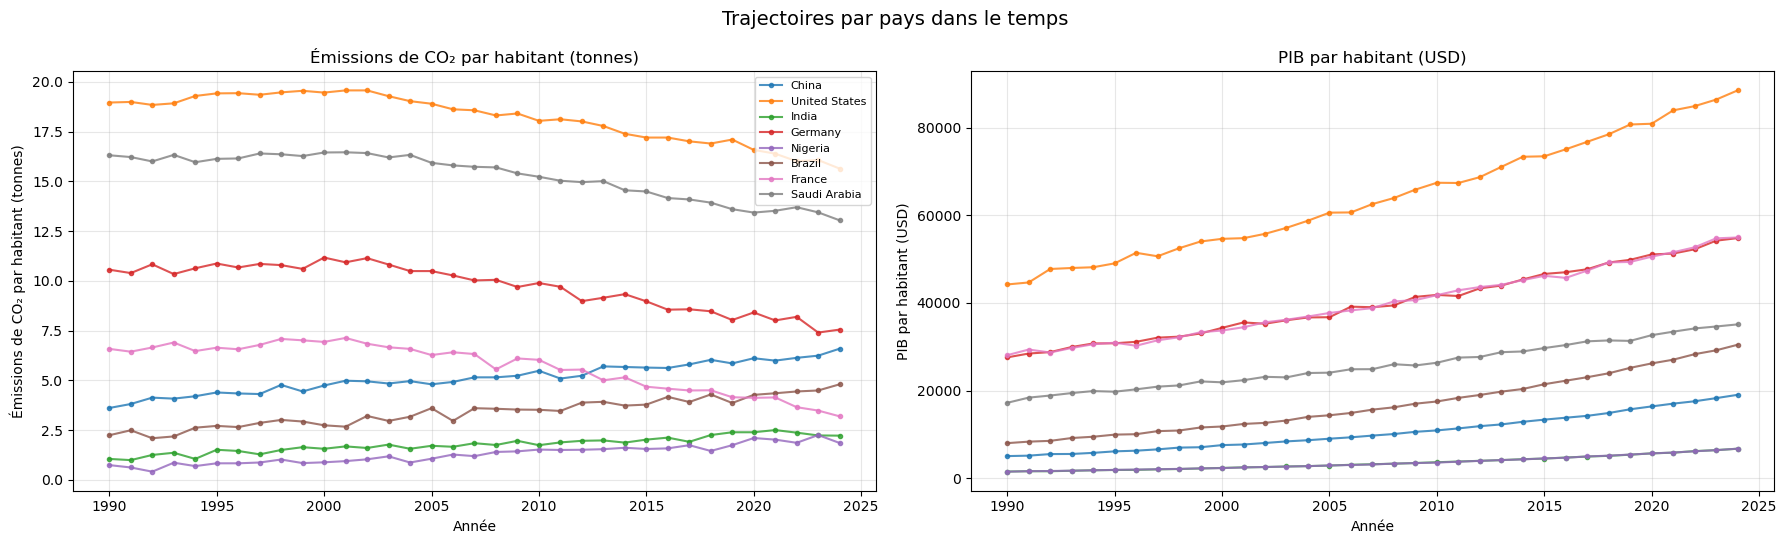

In [250]:
# Trajectoires par pays dans le temps (quelques pays représentatifs)
sample_countries = ['China','United States','India','Germany','Nigeria','Brazil','France','Saudi Arabia']
panels = [
    ('co2_per_capita', 'Émissions de CO₂ par habitant (tonnes)'),
    ('gdp_per_capita_usd', 'PIB par habitant (USD)'),
]

fig, axes = plt.subplots(1, 2, figsize=(18, 5.5), sharex=True)

for country in sample_countries:
    sub = df_annual[df_annual['country'] == country].sort_values('year')
    for ax, (col, label) in zip(axes, panels):
        ax.plot(sub['year'], sub[col], marker='o', markersize=3, label=country, alpha=0.8)

for ax, (col, label) in zip(axes, panels):
    ax.set_xlabel('Année')
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.grid(alpha=0.3)

axes[0].legend(fontsize=8)
plt.suptitle('Trajectoires par pays dans le temps', fontsize=14)
plt.tight_layout()
plt.show()


**Constat** : chaque pays trace bien une trajectoire unique. On observe par exemple que la France et les Etats Unis montrent une baisse de `co2_per_capita` sur la période récente malgré un PIB croissant (découplage richesse/émissions), alors que la Chine, l'Inde, le Nigeria sont en phase de hausse.

→ Ça confirme qu'il y a une vraie dynamique temporelle par pays à exploiter : **on va ajouter des features de lag (historique des années précédentes)** dans le preprocessing.

### PROBLEME DECOUVERT : 
La courbe du PIB pour la France et l'Allemagne sont exactement les mêmes. HORS ce n'est pas le cas, dans la réalité l'Allemagne a un PIB supérieur à celui de la France. Les données sont fausses  ou simulées ? 
Après vérifications : 
- les pays riches ont presque le même PIB/hab, et tous doublent leur PIB entre 1990 et 2024 ;
- aucune crise n'apparaît (2009, Covid 2020) ;
- des valeurs fausses : l'Inde compte 1,74 Md d'habitants, l'Allemagne 95 M, la Chine a un PIB/hab de 5 000 $ en 1990 ;
- la France et le Royaume‑Uni ont exactement la même population chaque année.

Pourtant sur Kaggle, il n'est pas écrit que ce sont des données simulées.

Conséquences :

la méthode reste valable, mais les conclusions ne s'appliquent pas au monde réel ;
les variables politiques (vraies données) ne peuvent pas avoir de lien avec des données simulées, ce qui explique leur absence d'effet

## 4. Preprocessing

**Étapes de cette section :**
1. Sélection de la cible et des features (avec exclusion des variables de fuite de données)
2. Gestion des valeurs manquantes
3. Création des features de lag (1, 2, 5 ans) et de moyenne mobile, pour donner au modèle l'historique récent de chaque pays — répond à la question "le PIB des années précédentes influence-t-il les émissions futures ?"
4. Split train/test **temporel** (pas aléatoire) : train = passé (1995-2016), test = futur jamais vu (2017-2024). Un split aléatoire mélangerait des années très proches d'un même pays entre train et test (ex: France 2015 en train, France 2016 en test), ce qui donnerait un score artificiellement gonflé — le split temporel simule honnêtement la vraie situation de déploiement (prédire l'avenir à partir du passé).
5. Encodage one-hot des variables catégorielles (`income_group`, `continent`), *fit* uniquement sur le train pour ne pas laisser d'information du test influencer le preprocessing.

In [251]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder

# --- Chargement et passage à l'échelle annuelle ---
df_annual = df_annual.sort_values(['country','year']).reset_index(drop=True)

# --- Définition de la cible et des features ---
target = 'co2_per_capita'

# Features numériques socio-économiques (variables de mode de vie / structure économique)
feature_cols = [
    'gdp_per_capita_usd','urbanization_rate','vehicle_ownership',
    'agriculture_share_gdp','industrial_share_gdp',
    'oil_production','share_coal_pct','share_renewables_pct',
    'forest_cover_pct','population_density'
]

# Features catégorielles
cat_cols = ['income_group','continent']

# On garde country/year à ce stade : nécessaires pour les lags (groupby) et le split temporel
# Elles seront explicitement retirées de X_train/X_test plus bas
df_model = df_annual[['country','year',target] + feature_cols + cat_cols].copy()

# --- Gestion des valeurs manquantes ---
# vehicle_ownership a quelques NaN : on impute par la médiane du pays lui-même
# (plus logique que la médiane globale, qui mélangerait des pays très différents)
df_model['vehicle_ownership'] = df_model.groupby('country')['vehicle_ownership']\
    .transform(lambda x: x.fillna(x.median()))
df_model['vehicle_ownership'] = df_model['vehicle_ownership'].fillna(df_model['vehicle_ownership'].median())

# --- Création des features de lag (historique) ---
# Pour chaque variable clé, on ajoute sa valeur il y a 1, 2 et 5 ans
# groupby('country') est essentiel : on ne veut jamais mélanger l'historique
# d'un pays avec celui d'un autre pays
lag_source_cols = ['gdp_per_capita_usd','urbanization_rate','vehicle_ownership',
                    'oil_production','share_coal_pct','share_renewables_pct']

for lag in [1, 2, 5]:
    for col in lag_source_cols:
        df_model[f'{col}_lag{lag}'] = df_model.groupby('country')[col].shift(lag)

# --- Moyenne mobile 5 ans (tendance récente lissée) ---
# .shift(1) pour ne pas inclure l'année actuelle dans sa propre moyenne (fuite de données)
for col in lag_source_cols:
    df_model[f'{col}_ma5'] = df_model.groupby('country')[col]\
        .transform(lambda x: x.rolling(5, min_periods=1).mean().shift(1))

# Les premières années de chaque pays n'ont pas assez d'historique pour le lag5 -> NaN -> on les retire
df_model = df_model.dropna().reset_index(drop=True)

# --- Split train/test temporel ---
# Train = passé (1995-2016), Test = futur jamais vu (2017-2024)
# Volontairement PAS aléatoire : on veut tester la capacité à prédire le futur, pas mémoriser
train = df_model[df_model['year'] <= 2016].copy()
test  = df_model[df_model['year'] > 2016].copy()

# --- Encodage des variables catégorielles (one-hot) ---
# Le OneHotEncoder est "fit" uniquement sur le train, pour ne jamais laisser
# d'information du test influencer le preprocessing (fuite de données)
num_cols = [c for c in df_model.columns if c not in ['country','year',target]+cat_cols]

enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
enc.fit(train[cat_cols])

train_cat = pd.DataFrame(enc.transform(train[cat_cols]),
                          columns=enc.get_feature_names_out(cat_cols), index=train.index)
test_cat = pd.DataFrame(enc.transform(test[cat_cols]),
                         columns=enc.get_feature_names_out(cat_cols), index=test.index)

# country et year sont ici volontairement exclues de X_train/X_test :
# ce ne sont pas des features numériques exploitables telles quelles par le modèle
X_train = pd.concat([train[num_cols], train_cat], axis=1)
X_test  = pd.concat([test[num_cols], test_cat], axis=1)
y_train = train[target]
y_test  = test[target]

print(f"Train: {X_train.shape[0]} lignes, {X_train.shape[1]} features")
print(f"Test:  {X_test.shape[0]} lignes")

df_model.head()

Train: 660 lignes, 44 features
Test:  240 lignes


,country,year,co2_per_capita,gdp_per_capita_usd,urbanization_rate,vehicle_ownership,agriculture_share_gdp,industrial_share_gdp,oil_production,share_coal_pct,...,vehicle_ownership_lag5,oil_production_lag5,share_coal_pct_lag5,share_renewables_pct_lag5,gdp_per_capita_usd_ma5,urbanization_rate_ma5,vehicle_ownership_ma5,oil_production_ma5,share_coal_pct_ma5,share_renewables_pct_ma5
0,Argentina,1995,4.23,11130.0,90.9,282.0,8,23,0.55,1.5,...,264.0,0.51,2.3,9.4,9605.6,90.68,275.4,0.526,2.16,9.06
1,Argentina,1996,4.50,11545.0,92.5,282.0,8,23,0.48,1.2,...,276.0,0.56,2.5,8.0,10081.8,91.06,279.0,0.534,2.00,9.36
2,Argentina,1997,4.44,11890.0,93.1,265.0,8,23,0.55,1.9,...,278.0,0.53,1.7,9.7,10506.6,91.58,280.2,0.518,1.74,9.98
3,Argentina,1998,4.43,12338.0,93.3,302.0,8,23,0.50,0.1,...,284.0,0.52,1.7,8.6,10976.6,91.82,277.6,0.522,1.78,9.76
4,Argentina,1999,5.02,13053.0,92.4,287.0,8,23,0.52,0.4,...,275.0,0.51,2.6,9.6,11439.6,92.40,281.2,0.518,1.46,10.28


# Partie 1 : le profil socio-économique explique-t-il les différences entre pays ?

On a vu que 96,9 % de la variance du CO₂/hab vient des **différences entre pays**. La première question est donc : à partir de son seul profil socio-économique, peut-on prédire le CO₂/hab d'un pays **que le modèle n'a jamais vu** ?

**Méthode : validation croisée « un pays de côté »** (`LeaveOneGroupOut`) : le modèle est entraîné sur 29 pays puis prédit le 30e, et on recommence pour chacun des 30 pays. Le modèle ne peut donc pas « reconnaître » le pays : il doit s'appuyer sur son profil.
- Variables : les 10 variables socio-économiques de l'année courante + `income_group` et `continent` (pas d'historique).
- Modèles : une **référence** (moyenne des 29 autres pays), une **régression linéaire** et un **Random Forest** (mêmes réglages qu'en section 5, sans optimisation : avec 30 pays, un réglage fin serait peu fiable).

,Model,MAE,R2 Score
0,Référence (moyenne des 29 autres pays),3.973982,-0.067957
1,Régression linéaire,2.878243,0.414474
2,Random Forest,1.891530,0.656031


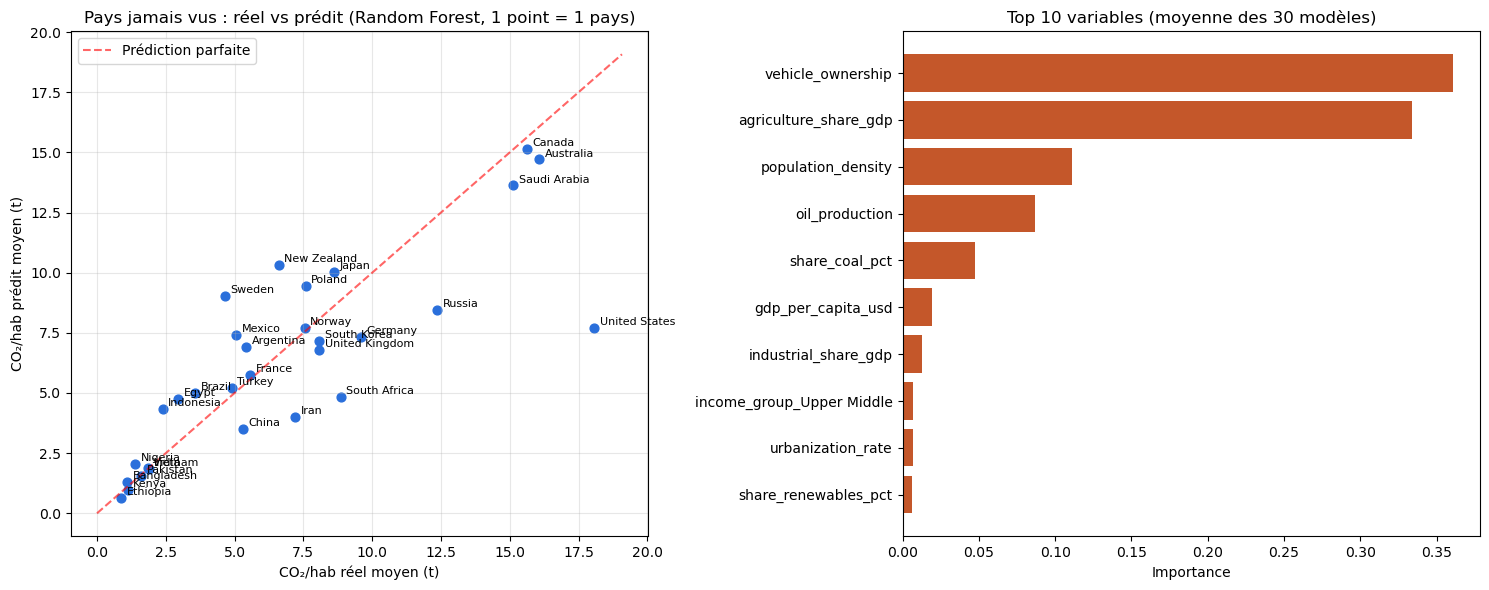

                 réel  prédit  erreur signée
country                                     
United States   18.08    7.70         -10.38
South Africa     8.86    4.82          -4.03
Russia          12.37    8.44          -3.93
Iran             7.20    4.01          -3.18
Germany          9.60    7.32          -2.28
China            5.30    3.50          -1.80
Saudi Arabia    15.13   13.63          -1.50
Australia       16.06   14.71          -1.35
United Kingdom   8.08    6.79          -1.30
South Korea      8.07    7.18          -0.89
Canada          15.62   15.13          -0.49
Ethiopia         0.88    0.64          -0.25
Kenya            1.11    0.97          -0.14
Pakistan         1.59    1.54          -0.05
India            1.88    1.83          -0.05
Vietnam          1.84    1.86           0.03
Norway           7.54    7.70           0.15
France           5.57    5.75           0.18
Bangladesh       1.08    1.31           0.22
Turkey           4.90    5.20           0.30
Nigeria   

In [252]:
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Mêmes lignes que df_model (1995-2024), mais uniquement les variables de l'année courante :
# on veut savoir si le PROFIL d'un pays suffit à prédire son CO2/hab, sans aucun historique
X_cs = pd.get_dummies(df_model[feature_cols + cat_cols], columns=cat_cols, dtype=float)
y_cs = df_model[target].values
groups_cs = df_model['country'].values

# Validation croisée "un pays de côté" : entraînement sur 29 pays, prédiction du 30e, 30 fois
pred_cs = {name: np.zeros(len(y_cs)) for name in ['Référence (moyenne des 29 autres pays)', 'Régression linéaire', 'Random Forest']}
importances_cs = np.zeros(X_cs.shape[1])
for tr, te in LeaveOneGroupOut().split(X_cs, y_cs, groups_cs):
    pred_cs['Référence (moyenne des 29 autres pays)'][te] = y_cs[tr].mean()
    pred_cs['Régression linéaire'][te] = LinearRegression().fit(X_cs.iloc[tr], y_cs[tr]).predict(X_cs.iloc[te])
    rf_cs = RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42, n_jobs=-1)   # mêmes réglages qu'en section 5
    rf_cs.fit(X_cs.iloc[tr], y_cs[tr])
    pred_cs['Random Forest'][te] = rf_cs.predict(X_cs.iloc[te])
    importances_cs += rf_cs.feature_importances_ / len(set(groups_cs))

results_cs = pd.DataFrame([{'Model': name, 'MAE': mean_absolute_error(y_cs, p), 'R2 Score': r2_score(y_cs, p)}
                           for name, p in pred_cs.items()])
display(results_cs)

# Erreur moyenne par pays (Random Forest)
err_pays_cs = pd.DataFrame({'country': groups_cs, 'réel': y_cs, 'prédit': pred_cs['Random Forest']})\
    .groupby('country').mean()
err_pays_cs['erreur signée'] = err_pays_cs['prédit'] - err_pays_cs['réel']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1) Réel vs prédit : 1 point = 1 pays (moyenne sur 1995-2024)
ax = axes[0]
ax.scatter(err_pays_cs['réel'], err_pays_cs['prédit'], color='#2a6fdb', s=40)
for pays, row in err_pays_cs.iterrows():
    ax.annotate(pays, (row['réel'], row['prédit']), fontsize=8, xytext=(4, 2), textcoords='offset points')
lim = [0, err_pays_cs[['réel', 'prédit']].max().max() + 1]
ax.plot(lim, lim, 'r--', alpha=0.6, label='Prédiction parfaite')
ax.set_xlabel('CO₂/hab réel moyen (t)')
ax.set_ylabel('CO₂/hab prédit moyen (t)')
ax.set_title('Pays jamais vus : réel vs prédit (Random Forest, 1 point = 1 pays)')
ax.legend()
ax.grid(alpha=0.3)

# 2) Importance des variables (moyenne sur les 30 modèles)
imp_cs = pd.Series(importances_cs, index=X_cs.columns).sort_values().tail(10)
axes[1].barh(imp_cs.index, imp_cs.values, color='#c4572a')
axes[1].set_title('Top 10 variables (moyenne des 30 modèles)')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

print(err_pays_cs.sort_values('erreur signée').round(2))

**Constat :**
- Le Random Forest explique environ **65 % des écarts entre pays jamais vus** (R² = 0,66, MAE = 1,89 t), contre une MAE de 3,97 t pour la référence et un R² de 0,41 pour la régression linéaire. **Le profil socio-économique prédit donc bien une partie du CO₂/hab.**
- Les variables les plus utiles sont la **motorisation** et la **part de l'agriculture** dans le PIB, puis la densité de population et la production de pétrole.
- Les erreurs sont très inégales : les pays pauvres et la France/Norvège sont bien prédits, mais les **États-Unis** sont fortement sous-estimés (7,7 t prédites pour 18,1 t) : aucun pays d'entraînement n'émet autant, et un Random Forest ne peut pas prédire au-delà des valeurs qu'il a vues. Les économies charbon/hydrocarbures (Afrique du Sud, Russie, Iran) sont sous-estimées, les pays riches à électricité décarbonée (Suède, Nouvelle-Zélande) surestimés.
- Limite : seulement 30 pays, donc 30 exemples réellement indépendants. Ces résultats sont indicatifs.

---

# Partie 2 : peut-on anticiper l'évolution des émissions dans le temps ?

La Partie 1 portait sur les différences **entre pays**. On s'intéresse maintenant à l'**évolution** d'un pays connu : à partir de son passé (1995-2016), peut-on prédire son CO₂/hab sur 2017-2024 ? On utilise pour cela le découpage temporel préparé en section 4.

## 5. Modélisation

Pour l'instant je décide de comparee deux modèles :
- **Régression linéaire** : simple, interprétable, sert de référence ("baseline")
- **Random Forest** : capture les non-linéarités et interactions entre variables.

In [253]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import joblib

# --- Modèle 1 : Régression linéaire (baseline simple/interprétable) ---
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

# --- Modèle 2 : Random Forest (capture non-linéarités et interactions) ---
rf = RandomForestRegressor(
    n_estimators=300,   # nombre d'arbres
    max_depth=8,        # profondeur max, limite le surapprentissage
    random_state=42,    # reproductibilité
    n_jobs=-1            # utilise tous les coeurs CPU disponibles
)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

# --- Évaluation ---
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"=== {name} ===")
    print(f"MAE:  {mae:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print(f"R²:   {r2:.3f}\n")

evaluate(y_test, pred_lr, "Régression Linéaire")
evaluate(y_test, pred_rf, "Random Forest")

joblib.dump({'rf':rf,'lr':lr,'X_train':X_train,'X_test':X_test,'y_train':y_train,'y_test':y_test,
             'pred_rf':pred_rf,'pred_lr':pred_lr,'test_meta':test[['country','year']]}, 'model_results.pkl')

=== Régression Linéaire ===
MAE:  1.628
RMSE: 2.039
R²:   0.767

=== Random Forest ===
MAE:  0.668
RMSE: 0.913
R²:   0.953



['model_results.pkl']

MAE = Mean Absolute Error = l'erreur moyenne -> plus grande avec régression linéaire, ce modèle se trompe plus. Pareil RMSE. 
R^2 = prédiction 

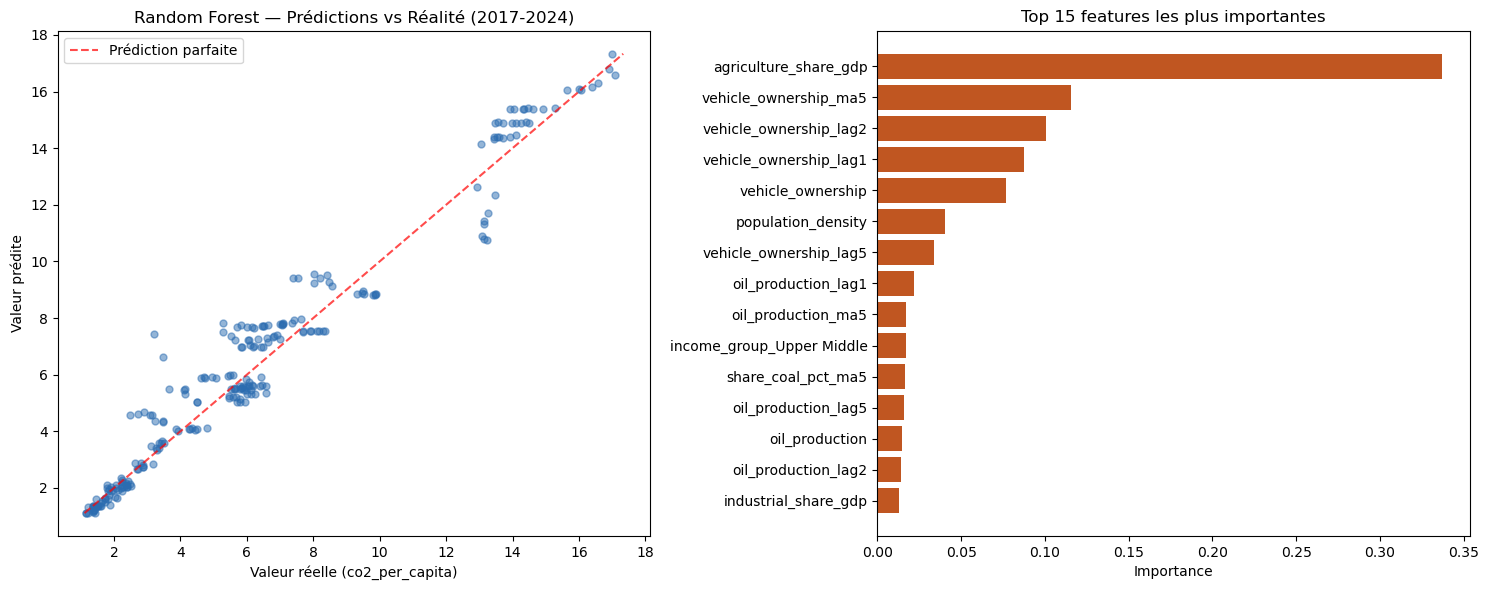

agriculture_share_gdp        0.336839
vehicle_ownership_ma5        0.115272
vehicle_ownership_lag2       0.100655
vehicle_ownership_lag1       0.087235
vehicle_ownership            0.076915
population_density           0.040252
vehicle_ownership_lag5       0.034063
oil_production_lag1          0.021586
oil_production_ma5           0.017253
income_group_Upper Middle    0.016890
share_coal_pct_ma5           0.016244
oil_production_lag5          0.015875
oil_production               0.014779
oil_production_lag2          0.014045
industrial_share_gdp         0.013207
dtype: float64


In [254]:
# Visualisation : prédictions vs réalité + feature importance (Random Forest baseline)
fig, axes = plt.subplots(1, 2, figsize=(15,6))

axes[0].scatter(y_test, pred_rf, alpha=0.5, s=25, color='#2b6cb0')
lims = [min(y_test.min(),pred_rf.min()), max(y_test.max(),pred_rf.max())]
axes[0].plot(lims, lims, 'r--', alpha=0.7, label='Prédiction parfaite')
axes[0].set_xlabel('Valeur réelle (co2_per_capita)')
axes[0].set_ylabel('Valeur prédite')
axes[0].set_title('Random Forest — Prédictions vs Réalité (2017-2024)')
axes[0].legend()

importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)
axes[1].barh(importances.index[::-1], importances.values[::-1], color='#c05621')
axes[1].set_xlabel('Importance')
axes[1].set_title('Top 15 features les plus importantes')

plt.tight_layout()
plt.show()
print(importances)

## 6. Optimisation des hyperparamètres (GridSearchCV)

Le Random Forest de la section 5 utilise des hyperparamètres choisis à la main (`n_estimators=300`, `max_depth=8`). On cherche ici systématiquement la meilleure combinaison avec une **recherche par grille** (`GridSearchCV`) : toutes les combinaisons de la grille sont testées.

**Validation croisée temporelle.** Une validation croisée classique (`KFold`) mélangerait les années : le modèle serait validé sur des années *entourées* d'années d'entraînement du même pays, ce qui est bien plus facile que prédire le futur. On construit donc 3 folds à l'intérieur du train (1995-2016), chacun respectant le temps :

| Fold | Entraînement | Validation |
|---|---|---|
| 1 | 1995-2010 | 2011-2012 |
| 2 | 1995-2012 | 2013-2014 |
| 3 | 1995-2014 | 2015-2016 |

Le critère est la **MAE moyenne sur les 3 validations**. Le **test (2017-2024) n'est jamais vu pendant la recherche** : la meilleure combinaison est réentraînée sur tout le train, puis évaluée une seule fois sur le test.

**Grille testée** (2 × 3 × 3 × 3 = 54 combinaisons, × 3 folds = 162 entraînements) :
- `n_estimators` (nombre d'arbres) : 100, 300
- `max_depth` (profondeur maximale) : 8, 16, illimitée
- `min_samples_leaf` (observations minimum par feuille, limite le surapprentissage) : 1, 3, 5
- `max_features` (part des variables testées à chaque division) : `sqrt`, 50 %, 100 %

In [255]:
from sklearn.model_selection import GridSearchCV, cross_val_score
import os, joblib

def modelresults(predictions, model_name):
    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    results_dict = {
        'Model': model_name,
        'MAE': mae,
        'MSE': mse,
        'R2 Score': r2
    }

    print('Results for {}:'.format(model_name))
    print('Mean absolute error on model is {:.4f}'.format(mae))
    print('Mean squared error on model is {:.4f}'.format(mse))
    print('The r2 score on model is {:.4f}'.format(r2))

    return results_dict

# --- Folds temporels à l'intérieur du train (1995-2016) ---
# Chaque fold entraîne sur toutes les années AVANT la fenêtre de validation, puis valide sur 2 ans
years_train = df_model.loc[X_train.index, 'year']
val_windows = [(2011, 2012), (2013, 2014), (2015, 2016)]

cv_temporal = []
for start, end in val_windows:
    fit_idx = np.where(years_train < start)[0]
    val_idx = np.where((years_train >= start) & (years_train <= end))[0]
    cv_temporal.append((fit_idx, val_idx))
    print(f"Fold validation {start}-{end} : entraînement 1995-{start-1} ({len(fit_idx)} lignes), validation {len(val_idx)} lignes")

param_grid = {
    'n_estimators': [100, 300],
    'max_depth': [8, 16, None],
    'min_samples_leaf': [1, 3, 5],
    'max_features': ['sqrt', 0.5, 1.0],
}

# Sauvegarde sur disque : si le fichier existe, on recharge la recherche au lieu de la relancer.
# /!\ Supprimer le fichier si les données, la grille ou les folds changent.
os.makedirs('cache_gridsearch', exist_ok=True)
cache_file = 'cache_gridsearch/grid_rf.pkl'
if os.path.exists(cache_file):
    grid = joblib.load(cache_file)
    print(f"\nRecherche rechargée depuis {cache_file}")
else:
    grid = GridSearchCV(
        RandomForestRegressor(random_state=42, n_jobs=-1),
        param_grid,
        cv=cv_temporal,
        scoring='neg_mean_absolute_error',
        return_train_score=True,
        refit=True,   # réentraîne la meilleure combinaison sur tout le train 1995-2016
    )
    grid.fit(X_train, y_train)
    joblib.dump(grid, cache_file)
    print(f"\nRecherche sauvegardée dans {cache_file}")

Fold validation 2011-2012 : entraînement 1995-2010 (480 lignes), validation 60 lignes
Fold validation 2013-2014 : entraînement 1995-2012 (540 lignes), validation 60 lignes
Fold validation 2015-2016 : entraînement 1995-2014 (600 lignes), validation 60 lignes

Recherche rechargée depuis cache_gridsearch/grid_rf.pkl


In [256]:
# --- Résultats de la recherche (validation temporelle uniquement) ---
print("Meilleurs hyperparamètres :", grid.best_params_)

# Même validation pour le RF non optimisé de la section 5, pour comparer à armes égales
mae_val_rf = -cross_val_score(rf, X_train, y_train, cv=cv_temporal, scoring='neg_mean_absolute_error').mean()
print(f"MAE validation - RF non optimisé : {mae_val_rf:.3f}")
print(f"MAE validation - RF optimisé     : {-grid.best_score_:.3f}")

# 10 meilleures combinaisons
cv_res = pd.DataFrame(grid.cv_results_).sort_values('rank_test_score')
top = pd.DataFrame({
    'n_estimators': cv_res['param_n_estimators'],
    'max_depth': cv_res['param_max_depth'],
    'min_samples_leaf': cv_res['param_min_samples_leaf'],
    'max_features': cv_res['param_max_features'],
    'MAE train': -cv_res['mean_train_score'],
    'MAE validation': -cv_res['mean_test_score'],
    'écart-type val.': cv_res['std_test_score'],
}).head(10)
print("\n10 meilleures combinaisons :")
print(top.round(3).to_string(index=False))

# --- Évaluation UNIQUE sur le test 2017-2024 ---
best_rf = grid.best_estimator_
pred_best_rf = best_rf.predict(X_test)

print()
results_rf = modelresults(pred_rf, 'Random Forest non optimisé (section 5)')
print()
results_grid = modelresults(pred_best_rf, 'Random Forest optimisé (GridSearch)')

pd.DataFrame([results_rf, results_grid])

Meilleurs hyperparamètres : {'max_depth': 16, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 300}
MAE validation - RF non optimisé : 0.383
MAE validation - RF optimisé     : 0.343

10 meilleures combinaisons :
 n_estimators max_depth  min_samples_leaf max_features  MAE train  MAE validation  écart-type val.
          300        16                 1         sqrt      0.065           0.343            0.012
          300      None                 1         sqrt      0.065           0.344            0.014
          100      None                 1         sqrt      0.068           0.346            0.013
          100        16                 1         sqrt      0.067           0.348            0.013
          300        16                 1          0.5      0.066           0.357            0.013
          300      None                 1          0.5      0.066           0.358            0.013
          300        16                 1          1.0      0.068           0.360

,Model,MAE,MSE,R2 Score
0,Random Forest non optimisé (section 5),0.667789,0.832931,0.953270
1,Random Forest optimisé (GridSearch),0.565665,0.625832,0.964889


**Interprétation :**
- **Meilleure combinaison** : 300 arbres, `max_depth=16`, `min_samples_leaf=1`, `max_features='sqrt'`.
- **Le paramètre décisif est `max_features`** : les 4 meilleures combinaisons utilisent `sqrt`. En ne laissant chaque division tester qu'une petite partie des 44 variables, on rend les arbres plus différents les uns des autres. C'est utile ici car beaucoup de variables sont presque redondantes (`vehicle_ownership`, ses lags et sa moyenne mobile, par exemple). À l'inverse, le nombre d'arbres (100 ou 300) et la profondeur (16 ou illimitée) ne changent presque rien (MAE 0,343 contre 0,344).
- **Gain de l'optimisation** : en validation, la MAE passe de 0,383 à 0,343 (-10 %). Sur le test 2017-2024, évalué une seule fois, elle passe de 0,668 à 0,566 (-15 %) et le R² de 0,953 à 0,965.
- **L'erreur de test (0,566) est bien plus forte qu'en validation (0,343)** : en validation, le modèle prédit 1 à 2 ans après la fin de l'entraînement, alors qu'au test il prédit jusqu'à 8 ans plus loin. La section 7.2 montre que l'erreur augmente avec cet éloignement.

## 7. Diagnostic du modèle optimisé

### 7.1 Courbes d'apprentissage : RF non optimisé vs optimisé

La courbe d'apprentissage indique si le modèle **sur-apprend** (grand écart entre l'erreur d'entraînement et l'erreur de validation) ou **sous-apprend** (les deux erreurs restent hautes), et si davantage de données aiderait.

Comme pour la recherche d'hyperparamètres, elle respecte le temps : pour chaque fenêtre de validation (2011-12, 2013-14, 2015-16), on entraîne le modèle sur les **k années qui la précèdent** (k = 3, 5, 8, 12, 16), sans jamais utiliser d'année future. Faire varier k fait varier la taille de l'entraînement. On trace la moyenne sur les 3 fenêtres (zone colorée = écart-type).

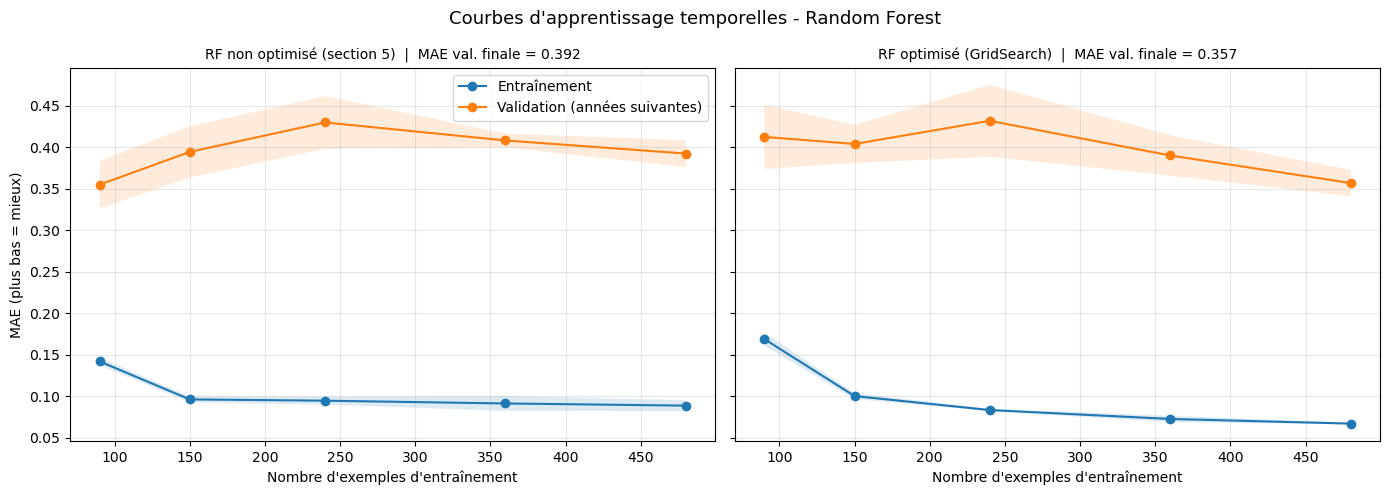

=== RF non optimisé (section 5) ===
 années  lignes  MAE train  MAE validation
      3    90.0      0.142           0.355
      5   150.0      0.096           0.394
      8   240.0      0.094           0.430
     12   360.0      0.091           0.408
     16   480.0      0.088           0.392 

=== RF optimisé (GridSearch) ===
 années  lignes  MAE train  MAE validation
      3    90.0      0.169           0.412
      5   150.0      0.100           0.404
      8   240.0      0.083           0.432
     12   360.0      0.072           0.390
     16   480.0      0.067           0.357 



In [257]:
from sklearn.base import clone

n_years_list = [3, 5, 8, 12, 16]   # 16 ans max : 1995-2010 avant la 1ère fenêtre

def temporal_learning_curve(model):
    sizes, train_mae, val_mae = [], [], []
    for k in n_years_list:
        tr_scores, va_scores, n_rows = [], [], []
        for start, end in val_windows:
            fit = (years_train >= start - k) & (years_train < start)
            val = (years_train >= start) & (years_train <= end)
            m = clone(model).fit(X_train[fit], y_train[fit])
            tr_scores.append(mean_absolute_error(y_train[fit], m.predict(X_train[fit])))
            va_scores.append(mean_absolute_error(y_train[val], m.predict(X_train[val])))
            n_rows.append(fit.sum())
        sizes.append(np.mean(n_rows))
        train_mae.append(tr_scores)
        val_mae.append(va_scores)
    return np.array(sizes), np.array(train_mae), np.array(val_mae)

models = {
    "RF non optimisé (section 5)": rf,
    "RF optimisé (GridSearch)": best_rf,
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
curves = {}

for ax, (name, model) in zip(axes, models.items()):
    sizes, tr, va = temporal_learning_curve(model)
    tr_mean, tr_std = tr.mean(axis=1), tr.std(axis=1)
    va_mean, va_std = va.mean(axis=1), va.std(axis=1)
    curves[name] = pd.DataFrame({'années': n_years_list, 'lignes': sizes.round(),
                                 'MAE train': tr_mean, 'MAE validation': va_mean})

    ax.plot(sizes, tr_mean, "o-", label="Entraînement")
    ax.fill_between(sizes, tr_mean - tr_std, tr_mean + tr_std, alpha=0.15)
    ax.plot(sizes, va_mean, "o-", label="Validation (années suivantes)")
    ax.fill_between(sizes, va_mean - va_std, va_mean + va_std, alpha=0.15)

    ax.set_title(f"{name}  |  MAE val. finale = {va_mean[-1]:.3f}", fontsize=10)
    ax.set_xlabel("Nombre d'exemples d'entraînement")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("MAE (plus bas = mieux)")
axes[0].legend()
fig.suptitle("Courbes d'apprentissage temporelles - Random Forest", fontsize=13)
plt.tight_layout()
plt.show()

for name, tab in curves.items():
    print(f"=== {name} ===")
    print(tab.round(3).to_string(index=False), "\n")

**Lecture :**
- **Erreur d'entraînement très basse (0,07-0,09) contre erreur de validation autour de 0,36-0,43** : l'écart est grand pour les deux modèles. Une erreur d'entraînement proche de 0 est normale pour un Random Forest, qui mémorise bien ses données. Ce qui compte, c'est le niveau de la courbe de validation et son évolution.
- **RF non optimisé** : la validation **ne s'améliore pas** quand on ajoute des années anciennes (0,355 avec 3 ans, 0,392 avec 16 ans). Les années lointaines n'aident pas à prédire les suivantes, voire gênent.
- **RF optimisé** : avec peu de données il est un peu moins bon (arbres plus profonds, donc plus de surapprentissage sur 90 lignes). En revanche, il **profite de l'historique** : sa validation descend de 0,43 à 0,357 avec 16 ans et finit sous celle du modèle non optimisé (0,392).
- **Conclusion** : l'optimisation améliore le modèle, mais l'écart entre entraînement et validation reste important (environ 0,29). Ajouter des années de même nature ne suffira pas à le combler : la limite vient plutôt de la façon de poser le problème (voir 7.3).

### 7.2 Analyse des erreurs du modèle optimisé

Jusqu'ici on a mesuré la performance globale (MAE, R²), mais un score moyen peut cacher des erreurs très inégalement réparties. On regarde ici **où précisément** le modèle optimisé se trompe sur le test 2017-2024 : par pays, par année, et si les erreurs sont aléatoires ou suivent un biais systématique (sur- ou sous-estimation récurrente sur certains pays).

=== Statistiques globales des erreurs ===
count    240.000000
mean       0.565665
std        0.554197
min        0.000661
25%        0.156775
50%        0.417767
75%        0.832826
max        3.289767
Name: abs_error, dtype: float64

=== Top 15 pires prédictions (erreur absolue) ===
country  year  y_true    y_pred     error  abs_error
 France  2024    3.19  6.479767  3.289767   3.289767
 Sweden  2024    2.48  5.172800  2.692800   2.692800
 France  2023    3.48  5.957013  2.477013   2.477013
 Sweden  2022    2.71  5.052060  2.342060   2.342060
 Sweden  2023    2.89  5.181967  2.291967   2.291967
 Poland  2024    5.27  7.469444  2.199444   2.199444
 Norway  2024    5.29  7.364000  2.074000   2.074000
Germany  2023    7.40  9.223333  1.823333   1.823333
 Sweden  2020    3.09  4.874067  1.784067   1.784067
 France  2022    3.65  5.372900  1.722900   1.722900
 Sweden  2021    3.14  4.847367  1.707367   1.707367
 Norway  2023    5.52  7.208933  1.688933   1.688933
 Russia  2023   13.25 11.5

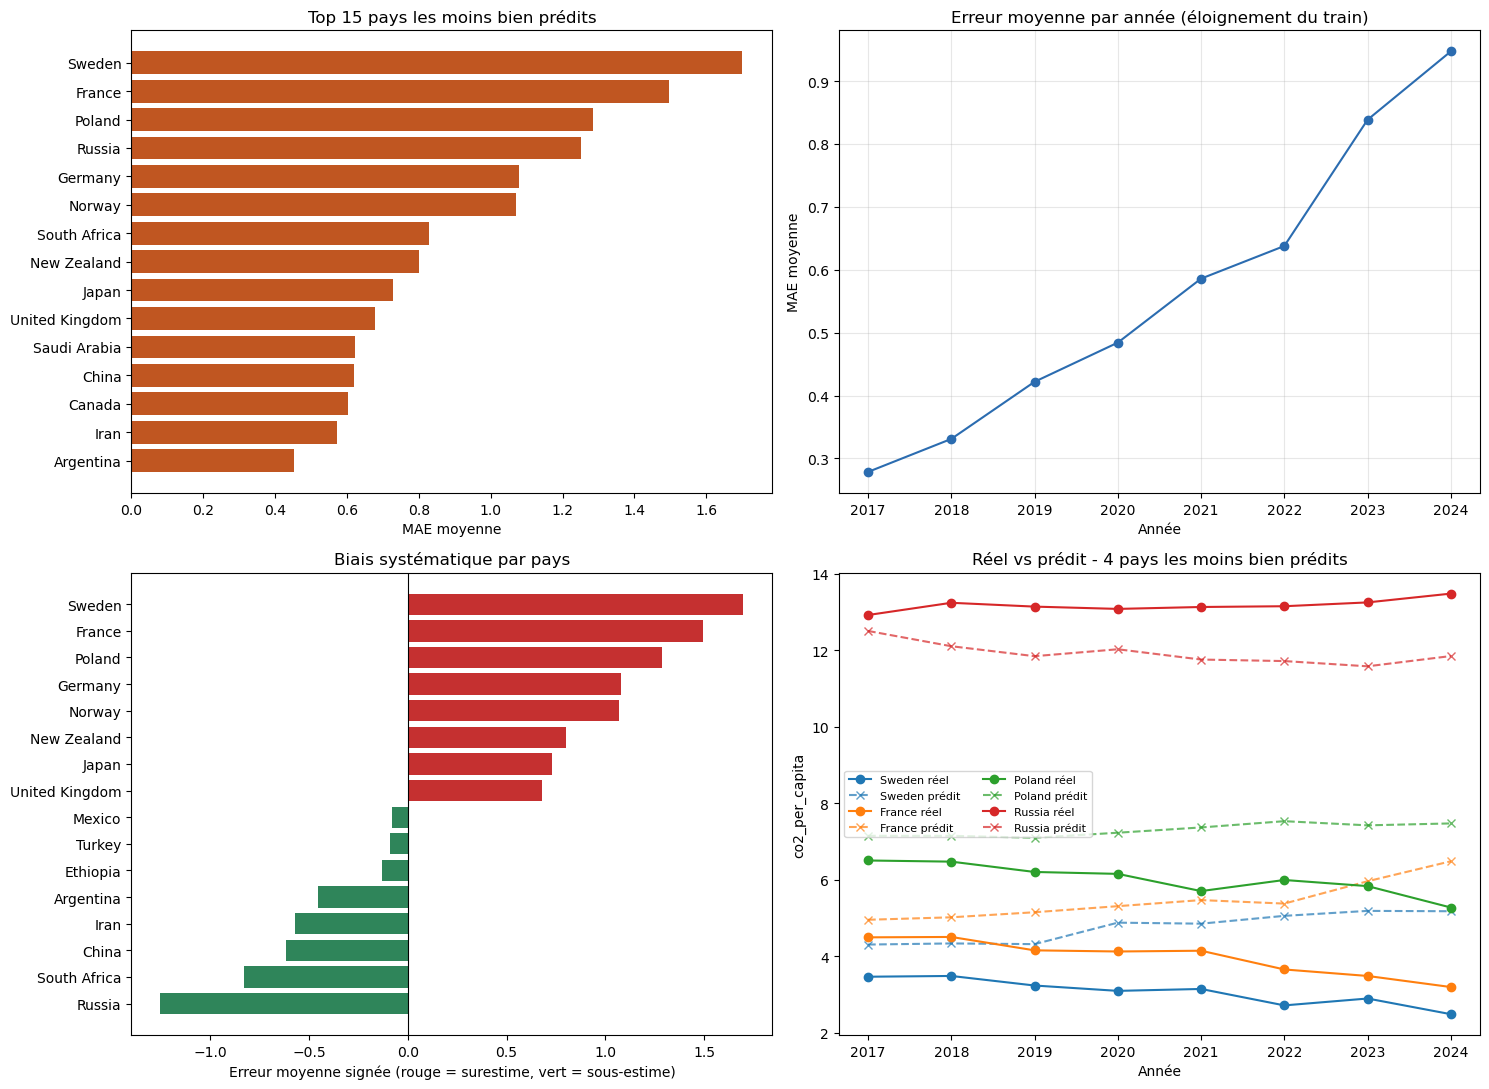

MAE par année :
year
2017    0.279
2018    0.331
2019    0.422
2020    0.484
2021    0.586
2022    0.638
2023    0.839
2024    0.947

Biais moyen par pays (8 plus fortes surestimations) :
country
Sweden            1.699
France            1.496
Poland            1.285
Germany           1.078
Norway            1.070
New Zealand       0.801
Japan             0.728
United Kingdom    0.678

Biais moyen par pays (8 plus fortes sous-estimations) :
country
Russia         -1.252
South Africa   -0.827
China          -0.619
Iran           -0.572
Argentina      -0.454
Ethiopia       -0.132
Turkey         -0.089
Mexico         -0.078


In [258]:
# Métadonnées (country, year) alignées avec X_test
test_meta = test[['country', 'year']]

results = test_meta.reset_index(drop=True).copy()
results['y_true'] = y_test.values
results['y_pred'] = pred_best_rf
results['error'] = results['y_pred'] - results['y_true']       # signé : positif = surestime, négatif = sous-estime
results['abs_error'] = results['error'].abs()                    # erreur absolue, pour classer les pires cas

print("=== Statistiques globales des erreurs ===")
print(results['abs_error'].describe())
print()
print("=== Top 15 pires prédictions (erreur absolue) ===")
print(results.sort_values('abs_error', ascending=False).head(15)
      [['country','year','y_true','y_pred','error','abs_error']].to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(15,11))

# --- 1. MAE par pays (les 15 moins bien prédits) ---
mae_by_country = results.groupby('country')['abs_error'].mean().sort_values(ascending=False)
top15 = mae_by_country.head(15)
axes[0,0].barh(top15.index[::-1], top15.values[::-1], color='#c05621')
axes[0,0].set_xlabel('MAE moyenne')
axes[0,0].set_title('Top 15 pays les moins bien prédits')

# --- 2. MAE par année (l'erreur augmente-t-elle avec l'éloignement du train ?) ---
mae_by_year = results.groupby('year')['abs_error'].mean()
axes[0,1].plot(mae_by_year.index, mae_by_year.values, marker='o', color='#2b6cb0')
axes[0,1].set_xlabel('Année')
axes[0,1].set_ylabel('MAE moyenne')
axes[0,1].set_title('Erreur moyenne par année (éloignement du train)')
axes[0,1].grid(alpha=0.3)

# --- 3. Biais systématique : erreur SIGNÉE moyenne par pays ---
bias_by_country = results.groupby('country')['error'].mean().sort_values()
top_bias = pd.concat([bias_by_country.head(8), bias_by_country.tail(8)])
colors = ['#2f855a' if v < 0 else '#c53030' for v in top_bias.values]  # vert = sous-estime, rouge = surestime
axes[1,0].barh(top_bias.index, top_bias.values, color=colors)
axes[1,0].axvline(0, color='black', linewidth=0.8)
axes[1,0].set_xlabel('Erreur moyenne signée (rouge = surestime, vert = sous-estime)')
axes[1,0].set_title('Biais systématique par pays')

# --- 4. Zoom sur les 4 pays les moins bien prédits : réel vs prédit dans le temps ---
for c in mae_by_country.index[:4]:
    sub = results[results['country']==c].sort_values('year')
    line, = axes[1,1].plot(sub['year'], sub['y_true'], marker='o', label=f'{c} réel')
    axes[1,1].plot(sub['year'], sub['y_pred'], marker='x', linestyle='--', alpha=0.7,
                   color=line.get_color(), label=f'{c} prédit')
axes[1,1].set_xlabel('Année')
axes[1,1].set_ylabel('co2_per_capita')
axes[1,1].set_title('Réel vs prédit - 4 pays les moins bien prédits')
axes[1,1].legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

print("MAE par année :")
print(mae_by_year.round(3).to_string())
print("\nBiais moyen par pays (8 plus fortes surestimations) :")
print(bias_by_country.tail(8)[::-1].round(3).to_string())
print("\nBiais moyen par pays (8 plus fortes sous-estimations) :")
print(bias_by_country.head(8).round(3).to_string())

**Interprétation :**

**1. L'erreur augmente avec l'éloignement temporel** (en haut à droite). La MAE passe de 0,28 en 2017 à 0,95 en 2024, soit plus de 3 fois plus. Plus on prédit loin de la période d'entraînement (1995-2016), moins le modèle est fiable.

**2. Un biais systématique par pays, pas un bruit aléatoire** (en bas à gauche). Le modèle **surestime** de façon récurrente un groupe de pays riches engagés dans la transition énergétique : Suède (+1,7 t/hab en moyenne), France (+1,5), Pologne, Allemagne, Norvège, Nouvelle-Zélande, Japon, Royaume-Uni. Il **sous-estime** un autre groupe, surtout des pays producteurs d'énergies fossiles ou fortement émetteurs : Russie (-1,25), Afrique du Sud, Chine, Iran, Argentine.

**3. D'où vient ce biais ?** (en bas à droite) Pour la Suède, la France et la Pologne, le CO₂/hab réel **baisse** sur 2017-2024, alors que la prédiction **stagne, voire augmente**, en suivant la hausse du PIB et de la motorisation. L'écart existe dès 2017 puis se creuse. Pour la Russie, c'est l'inverse : la valeur réelle reste stable vers 13 t/hab et le modèle la sous-estime d'environ 1 à 1,5 t/hab.

L'optimisation par GridSearch a réduit l'erreur de test de 15 %, mais le diagnostic montre une limite structurelle :
- l'erreur **triple entre 2017 et 2024** ;
- le modèle se trompe **toujours dans le même sens** pour un même pays ;
- le R² élevé (0,965) est trompeur : il vient surtout des **écarts entre pays** (la Russie émet beaucoup plus que l'Éthiopie), que le modèle reconnaît facilement à partir de variables quasi constantes, et non de sa capacité à suivre **l'évolution** d'un pays dans le temps.

Une question s'impose alors : le modèle fait-il mieux qu'un modèle **naïf**, sans apprentissage, qui répète simplement la dernière valeur connue (2016) de chaque pays ? La section 8 montre que non (MAE 0,448 pour le naïf contre 0,566 pour le RF optimisé). Plutôt que d'optimiser davantage le même modèle, on **change la façon de poser le problème** : partir de la dernière valeur connue de chaque pays et ne prédire que sa **variation**.

## 8. Amélioration du modèle : prédire la variation depuis la dernière année connue

**Constat.** Un *modèle naïf* (aucun apprentissage : « le CO₂/hab de chaque pays reste celui de 2016 ») fait mieux sur le test que les Random Forest des sections 5 et 6, y compris le modèle optimisé. Le R² de 0,97 venait surtout des écarts *entre pays* : le modèle reconnaît le pays (via des variables quasi constantes comme `forest_cover_pct` ou `population_density`) mais apprend mal l'**évolution dans le temps**.

**Idée.** Au lieu de prédire le niveau `y(t)`, on prédit la **variation depuis une année d'ancrage b connue** :

$$y(t) = y(b) + \widehat{\Delta}, \quad \Delta = y(t) - y(b)$$

avec comme features : les variations des variables socio-économiques `X(t) - X(b)`, leur niveau `X(t)`, et l'horizon `h = t - b` (1 à 8 ans).

- **Entraînement** : toutes les paires (b, t) avec b < t ≤ 2016 et t - b ≤ 8 (chaque pays fournit beaucoup d'exemples de « trajectoires »).
- **Test** : ancre b = 2016 (dernière année connue), cibles 2017-2024 → exactement la situation réelle de prévision.
- Choix du modèle sur la **validation** (ancre 2012 → 2013-2016), test utilisé une seule fois.

In [259]:
# --- Modèle naïf (référence à battre) : on répète la valeur 2016 de chaque pays ---
test_keys = df_model.loc[X_test.index, ['country', 'year']]
last_2016 = df_model[df_model['year'] == 2016].set_index('country')[target]
y_pred_naive = test_keys['country'].map(last_2016).values

results_naive = modelresults(y_pred_naive, 'Naïf (valeur 2016 répétée)')

Results for Naïf (valeur 2016 répétée):
Mean absolute error on model is 0.4485
Mean squared error on model is 0.3309
The r2 score on model is 0.9814


In [260]:
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# --- Construction des paires (ancre b, cible t) ---
# Liste fixe des 10 variables socio-économiques : on n'utilise pas feature_cols,
# car la partie « variables politiques » lui ajoute left_right / has_left_right (absentes de df_model)
delta_cols = ['gdp_per_capita_usd','urbanization_rate','vehicle_ownership',
              'agriculture_share_gdp','industrial_share_gdp',
              'oil_production','share_coal_pct','share_renewables_pct',
              'forest_cover_pct','population_density']
base = df_model[['country', 'year', target] + delta_cols]

def make_pairs(anchor_years, target_min, target_max, hmax=8):
    """Une ligne par (pays, année d'ancrage b, année cible t) avec 1 <= t - b <= hmax."""
    b = base[base['year'].isin(anchor_years)]
    t = base[(base['year'] >= target_min) & (base['year'] <= target_max)]
    p = t.merge(b, on='country', suffixes=('', '_b'))
    p['h'] = p['year'] - p['year_b']
    p = p[(p['h'] >= 1) & (p['h'] <= hmax)].copy()
    for f in delta_cols:
        p['d_' + f] = p[f] - p[f + '_b']      # variation de la variable depuis l'ancre
    p['delta'] = p[target] - p[target + '_b']  # cible : variation du CO2/hab depuis l'ancre
    return p

delta_features = ['h'] + ['d_' + f for f in delta_cols] + delta_cols

# Validation : entraînement sur les paires <= 2012, prédiction de 2013-2016 depuis l'ancre 2012
pairs_fit = make_pairs(range(1995, 2012), 1995, 2012)
pairs_val = make_pairs([2012], 2013, 2016)
print(f"Paires d'entraînement (validation) : {len(pairs_fit)} | paires de validation : {len(pairs_val)}")

candidates = {
    "Ridge (variation)": make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-3, 3, 20))),
    "RF (variation)": RandomForestRegressor(n_estimators=300, min_samples_leaf=5, random_state=42, n_jobs=-1),
}

print(f"\nMAE validation 2013-2016 :")
print(f"  {'Naïf (valeur 2012)':22s} {mean_absolute_error(pairs_val[target], pairs_val[target + '_b']):.3f}")
for name, m in candidates.items():
    m.fit(pairs_fit[delta_features], pairs_fit['delta'])
    pred = pairs_val[target + '_b'] + m.predict(pairs_val[delta_features])
    print(f"  {name:22s} {mean_absolute_error(pairs_val[target], pred):.3f}")

Paires d'entraînement (validation) : 3240 | paires de validation : 120

MAE validation 2013-2016 :
  Naïf (valeur 2012)     0.320
  Ridge (variation)      0.237
  RF (variation)         0.195


In [261]:
# --- Modèle retenu (meilleur en validation) : RF sur la variation ---
# Réentraîné sur toutes les paires <= 2016, puis évalué UNE SEULE FOIS sur 2017-2024 depuis l'ancre 2016
pairs_train = make_pairs(range(1995, 2016), 1995, 2016)
pairs_test = make_pairs([2016], 2017, 2024)

rf_delta = RandomForestRegressor(n_estimators=300, min_samples_leaf=5, random_state=42, n_jobs=-1)
rf_delta.fit(pairs_train[delta_features], pairs_train['delta'])
pairs_test['pred'] = pairs_test[target + '_b'] + rf_delta.predict(pairs_test[delta_features])

# Remise dans le même ordre que y_test pour réutiliser modelresults
y_pred_rf_delta = (test_keys.merge(pairs_test[['country', 'year', 'pred']], on=['country', 'year'], how='left')['pred'].values)

results_rf_delta = modelresults(y_pred_rf_delta, 'RF sur la variation depuis 2016')

# R² sur la VARIATION depuis 2016 (test) : mesure uniquement ce que le modèle a dû prédire,
# sans le niveau de départ du pays (déjà connu), qui gonfle le R² sur le niveau
d_true = pairs_test[target] - pairs_test[target + '_b']
print()
print(f"R² sur la variation (test) - RF sur la variation : {r2_score(d_true, pairs_test['pred'] - pairs_test[target + '_b']):.3f}")
print(f"R² sur la variation (test) - Naïf (variation = 0) : {r2_score(d_true, np.zeros(len(d_true))):.3f}")

# --- Tableau récapitulatif sur le test 2017-2024 ---
results_all = pd.DataFrame([results_naive, results_rf, results_grid, results_rf_delta]).sort_values('MAE')
results_all

Results for RF sur la variation depuis 2016:
Mean absolute error on model is 0.1905
Mean squared error on model is 0.0602
The r2 score on model is 0.9966

R² sur la variation (test) - RF sur la variation : 0.806
R² sur la variation (test) - Naïf (variation = 0) : -0.065


,Model,MAE,MSE,R2 Score
3,RF sur la variation depuis 2016,0.190500,0.060150,0.996625
0,Naïf (valeur 2016 répétée),0.448458,0.330945,0.981433
2,Random Forest optimisé (GridSearch),0.565665,0.625832,0.964889
1,Random Forest non optimisé (section 5),0.667789,0.832931,0.953270


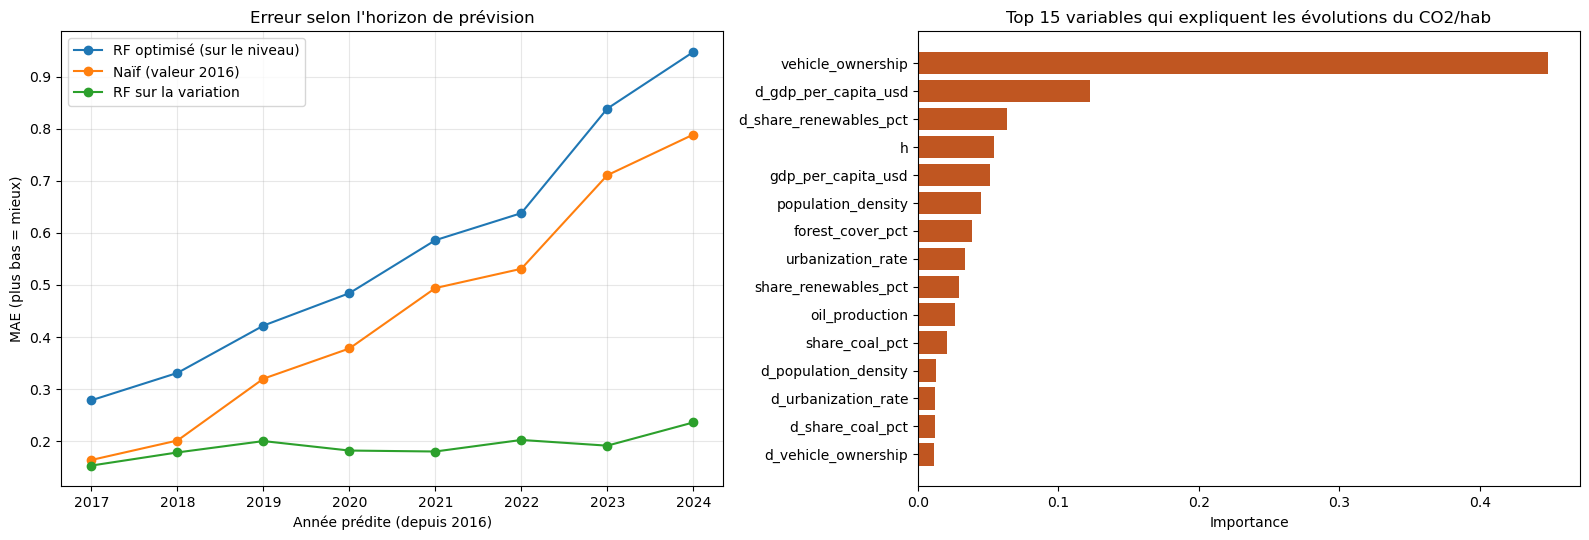

vehicle_ownership         0.448974
d_gdp_per_capita_usd      0.122759
d_share_renewables_pct    0.063482
h                         0.054218
gdp_per_capita_usd        0.050896
population_density        0.044798
forest_cover_pct          0.038067
urbanization_rate         0.033105
share_renewables_pct      0.029450
oil_production            0.026138
share_coal_pct            0.020605
d_population_density      0.012942
d_urbanization_rate       0.012125
d_share_coal_pct          0.011990
d_vehicle_ownership       0.011032
dtype: float64


In [262]:
# Erreur selon l'horizon de prévision : RF optimisé (niveau) vs naïf vs RF sur la variation
err = pd.DataFrame({
    'year': test_keys['year'].values,
    'RF optimisé (sur le niveau)': np.abs(y_test.values - pred_best_rf),
    'Naïf (valeur 2016)': np.abs(y_test.values - y_pred_naive),
    'RF sur la variation': np.abs(y_test.values - y_pred_rf_delta),
}).groupby('year').mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

err.plot(marker='o', ax=axes[0])
axes[0].set_xlabel("Année prédite (depuis 2016)")
axes[0].set_ylabel("MAE (plus bas = mieux)")
axes[0].set_title("Erreur selon l'horizon de prévision")
axes[0].grid(alpha=0.3)

# Variables qui expliquent le mieux les évolutions du CO2/hab
importances_delta = pd.Series(rf_delta.feature_importances_, index=delta_features).sort_values(ascending=False).head(15)
axes[1].barh(importances_delta.index[::-1], importances_delta.values[::-1], color='#c05621')
axes[1].set_xlabel('Importance')
axes[1].set_title('Top 15 variables qui expliquent les évolutions du CO2/hab')

plt.tight_layout()
plt.show()
print(importances_delta)

#### Courbe d'apprentissage temporelle du modèle sur la variation

Même principe que les courbes temporelles précédentes (mêmes fenêtres de validation 2011-12, 2013-14, 2015-16, mêmes nombres d'années k), adapté aux paires :
- pour chaque fenêtre, l'**ancre** est l'année juste avant (2010, 2012, 2014) ;
- le modèle est entraîné sur les paires dont les années sont comprises dans les **k années précédant l'ancre** (jamais d'année future) ;
- il prédit la fenêtre depuis l'ancre ; on compare au **naïf** (valeur de l'ancre répétée), en pointillés.

L'axe X compte les **paires** d'entraînement (une même année sert dans plusieurs paires, d'où des nombres plus grands que pour les courbes précédentes).

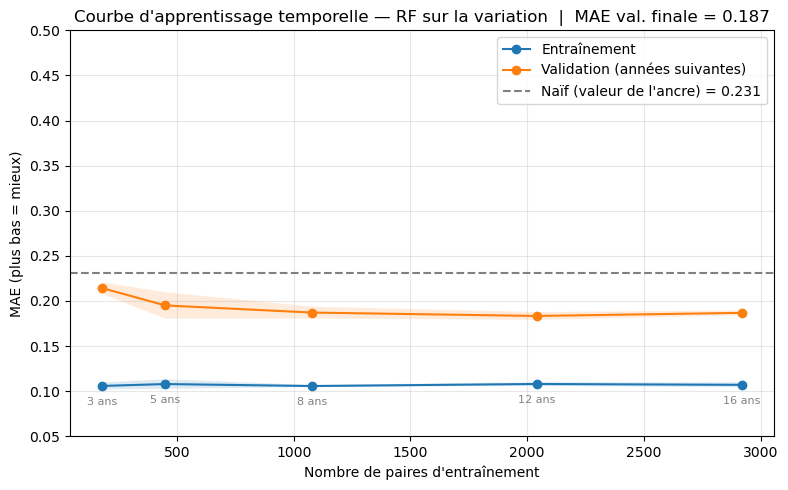

In [263]:
from sklearn.base import clone

val_windows = [(2011, 2012), (2013, 2014), (2015, 2016)]
n_years_list = [3, 5, 8, 12, 16]
rf_delta_template = RandomForestRegressor(n_estimators=300, min_samples_leaf=5, random_state=42, n_jobs=-1)

sizes, train_mae, val_mae, naive_mae = [], [], [], []
for k in n_years_list:
    tr_s, va_s, na_s, n_pairs = [], [], [], []
    for start, end in val_windows:
        a = start - 1                                   # ancre = dernière année connue
        first = max(a - k, 1995)
        p_fit = make_pairs(range(first, a), first, a)   # paires entièrement dans [a-k, a]
        p_val = make_pairs([a], start, end)

        m = clone(rf_delta_template).fit(p_fit[delta_features], p_fit['delta'])
        # Erreur sur la variation = erreur sur le niveau (la valeur de l'ancre est connue)
        tr_s.append(mean_absolute_error(p_fit['delta'], m.predict(p_fit[delta_features])))
        va_s.append(mean_absolute_error(p_val['delta'], m.predict(p_val[delta_features])))
        na_s.append(mean_absolute_error(p_val['delta'], np.zeros(len(p_val))))  # naïf : variation nulle
        n_pairs.append(len(p_fit))
    sizes.append(np.mean(n_pairs)); train_mae.append(tr_s); val_mae.append(va_s); naive_mae.append(na_s)

sizes, train_mae, val_mae = np.array(sizes), np.array(train_mae), np.array(val_mae)
naive_level = np.mean(naive_mae)   # ne dépend pas de k : même valeur pour tous les points

tr_mean, tr_std = train_mae.mean(axis=1), train_mae.std(axis=1)
va_mean, va_std = val_mae.mean(axis=1), val_mae.std(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(sizes, tr_mean, "o-", label="Entraînement")
plt.fill_between(sizes, tr_mean - tr_std, tr_mean + tr_std, alpha=0.15)
plt.plot(sizes, va_mean, "o-", label="Validation (années suivantes)")
plt.fill_between(sizes, va_mean - va_std, va_mean + va_std, alpha=0.15)
plt.axhline(naive_level, color="grey", linestyle="--", label=f"Naïf (valeur de l'ancre) = {naive_level:.3f}")
for x, k in zip(sizes, n_years_list):
    plt.annotate(f"{k} ans", (x, tr_mean[n_years_list.index(k)]), textcoords="offset points", xytext=(0, -14),
                 ha="center", fontsize=8, color="grey")
plt.xlabel("Nombre de paires d'entraînement")
plt.ylabel("MAE (plus bas = mieux)")
plt.ylim(0.05, 0.5)   # même échelle que les courbes temporelles du RF sur le niveau
plt.title(f"Courbe d'apprentissage temporelle — RF sur la variation  |  MAE val. finale = {va_mean[-1]:.3f}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Lecture :**
- Le modèle sur la variation doit être comparé au **naïf**, pas seulement aux autres Random Forest : c'est lui qui montre si le modèle apprend vraiment la dynamique.
- Le graphique par horizon montre si le gain tient quand on prédit loin (2023-2024) ou seulement à court terme.
- Les importances portent maintenant sur les **évolutions** : elles répondent à « quelles variables expliquent que le CO₂/hab d'un pays augmente ou baisse ? », ce qui est plus proche de la question de départ que « quelles variables distinguent les pays ».
- Hypothèse à garder en tête (comme pour les modèles précédents) : on suppose connues les variables socio-économiques de l'année prédite (PIB, part du charbon…). Pour une vraie prévision, il faudrait des projections de ces variables.

#### Optimisation du RF sur la variation (GridSearchCV)

Même démarche qu'en section 6 : validation temporelle sur 3 folds (ancres 2010, 2012, 2014 → prédiction des 2 années suivantes, entraînement sur les paires antérieures uniquement). Le test 2017-2024 n'est utilisé qu'une fois.

**Résultat :** le gain est négligeable. En validation, la MAE passe de 0,185 à 0,180. Sur le test, elle est même un peu moins bonne (0,200 contre 0,191 pour le réglage manuel), un écart de l'ordre du bruit. Les hyperparamètres ne sont donc pas le levier ici : **c'est le changement de cible (prédire la variation) qui apporte le gain**, pas le réglage du modèle.

In [264]:
# Folds temporels sur les paires <= 2016 : entraînement = paires finies avant l'ancre, validation = ancre -> 2 ans suivants
p_all = pairs_train.reset_index(drop=True)
cv_pairs = [(np.where(p_all['year'] <= a)[0],
             np.where((p_all['year_b'] == a) & (p_all['year'] > a) & (p_all['year'] <= a + 2))[0]) for a in [2010, 2012, 2014]]

cache_file = 'cache_gridsearch/grid_delta.pkl'
if os.path.exists(cache_file):
    grid_delta = joblib.load(cache_file)
else:
    grid_delta = GridSearchCV(RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
                              {'max_depth': [16, None], 'min_samples_leaf': [1, 3, 5, 10], 'max_features': ['sqrt', 0.5, 1.0]},
                              cv=cv_pairs, scoring='neg_mean_absolute_error', refit=True).fit(p_all[delta_features], p_all['delta'])
    joblib.dump(grid_delta, cache_file)

mae_val_manual = -cross_val_score(rf_delta, p_all[delta_features], p_all['delta'], cv=cv_pairs, scoring='neg_mean_absolute_error').mean()
print("Meilleurs hyperparamètres :", grid_delta.best_params_)
print(f"MAE validation - réglage manuel (min_samples_leaf=5) : {mae_val_manual:.3f} | GridSearch : {-grid_delta.best_score_:.3f}")
print()

# Évaluation UNIQUE sur le test 2017-2024 (ancre 2016)
pairs_test['pred_grid'] = pairs_test[target + '_b'] + grid_delta.best_estimator_.predict(pairs_test[delta_features])
y_pred_rf_delta_grid = test_keys.merge(pairs_test[['country', 'year', 'pred_grid']], on=['country', 'year'], how='left')['pred_grid'].values
results_rf_delta_grid = modelresults(y_pred_rf_delta_grid, 'RF sur la variation optimisé (GridSearch)')

Meilleurs hyperparamètres : {'max_depth': 16, 'max_features': 0.5, 'min_samples_leaf': 10}
MAE validation - réglage manuel (min_samples_leaf=5) : 0.185 | GridSearch : 0.180

Results for RF sur la variation optimisé (GridSearch):
Mean absolute error on model is 0.2004
Mean squared error on model is 0.0740
The r2 score on model is 0.9958


### 9. Essai : réseau de neurones récurrent (LSTM)

**Objectif :** comparer, à titre exploratoire, un modèle qui lit l'historique *année après année* au Random Forest sur la variation.

**Comment il fonctionne :**
- Pour chaque pays et chaque année t, on donne au LSTM la **séquence des L dernières années** (t-L+1, …, t) : pour chaque année, les 10 variables socio-économiques et leur variation annuelle.
- Le LSTM lit cette séquence dans l'ordre (comme on lit une phrase mot par mot) et prédit la **variation du CO₂/hab entre t-1 et t**.
- Pour le test, on part de la valeur 2016 et on **additionne** les variations prédites : CO₂(2018) = CO₂(2016) + Δ2017 + Δ2018, etc.

**Mêmes règles que les autres modèles :** hyperparamètres choisis sur la validation (entraînement ≤ 2012, prédiction de 2013-2016 depuis 2012), test 2017-2024 utilisé une seule fois. Même hypothèse : les variables socio-économiques de l'année prédite sont supposées connues ; le CO₂ après 2016, lui, ne l'est jamais.

**Limites attendues :** peu de données pour un réseau de neurones (30 pays × ~20 ans), et les erreurs annuelles s'**additionnent** sur 8 ans.

In [265]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"   # masque les messages techniques de TensorFlow
import tensorflow as tf

# --- Données annuelles + variations annuelles (d_ = valeur de l'année - valeur de l'année précédente) ---
seq_base = df_model[['country', 'year', target] + delta_cols].sort_values(['country', 'year']).copy()
for c in delta_cols + [target]:
    seq_base['d_' + c] = seq_base.groupby('country')[c].diff()
seq_inputs = delta_cols + ['d_' + c for c in delta_cols]   # 20 variables par année

def make_sequences(L, t_min, t_max, mean=None, std=None):
    """Une séquence par (pays, année t) : les L dernières années de variables -> variation du CO2 en t."""
    X, y, keys = [], [], []
    for country, g in seq_base.groupby('country'):
        g = g.set_index('year')
        for t in range(t_min, t_max + 1):
            years = list(range(t - L + 1, t + 1))
            if years[0] < g.index.min() + 1 or t not in g.index:   # la 1ère année n'a pas de variation
                continue
            X.append(g.loc[years, seq_inputs].values)
            y.append(g.at[t, 'd_' + target])
            keys.append((country, t))
    X, y = np.array(X, dtype='float32'), np.array(y, dtype='float32')
    # Standardisation (moyenne 0, écart-type 1), calculée sur l'entraînement uniquement
    if mean is None:
        flat = X.reshape(-1, X.shape[2])
        mean, std = flat.mean(axis=0), flat.std(axis=0) + 1e-6
    return (X - mean) / std, y, pd.DataFrame(keys, columns=['country', 'year']), mean, std

X_demo, y_demo, _, _, _ = make_sequences(5, 1995, 2016)
print("Forme des séquences (exemple L=5) :", X_demo.shape, "= (nb séquences, nb années, nb variables)")

Forme des séquences (exemple L=5) : (510, 5, 20) = (nb séquences, nb années, nb variables)


In [266]:
def build_lstm(L, units, dropout):
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(L, len(seq_inputs))),
        tf.keras.layers.LSTM(units, dropout=dropout),   # lit la séquence année par année
        tf.keras.layers.Dense(1),                        # sortie : variation du CO2/hab
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss='mae')
    return model

def fit_predict_lstm(L, units, dropout, train_end, anchor, eval_end, seeds=(0, 1, 2)):
    """Entraîne sur les années <= train_end, prédit anchor+1..eval_end en cumulant depuis l'ancre."""
    X_tr, y_tr, k_tr, mu, sd = make_sequences(L, 1995, train_end)
    order = np.argsort(k_tr['year'].values, kind='stable')   # tri par année : validation_split = années les plus récentes
    X_tr, y_tr = X_tr[order], y_tr[order]
    X_ev, _, k_ev, _, _ = make_sequences(L, anchor + 1, eval_end, mu, sd)

    preds, histories, models = [], [], []
    for seed in seeds:   # moyenne de 3 réseaux : un seul réseau varie beaucoup selon l'initialisation
        tf.keras.utils.set_random_seed(seed)
        model = build_lstm(L, units, dropout)
        h = model.fit(X_tr, y_tr, epochs=300, batch_size=32, validation_split=0.2, verbose=0,
                      callbacks=[tf.keras.callbacks.EarlyStopping(patience=30, restore_best_weights=True)])
        preds.append(model.predict(X_ev, verbose=0).ravel())
        histories.append(h.history)
        models.append(model)

    k_ev['d_pred'] = np.mean(preds, axis=0)
    k_ev = k_ev.sort_values(['country', 'year'])
    y_anchor = seq_base[seq_base['year'] == anchor].set_index('country')[target]
    k_ev['pred'] = k_ev['country'].map(y_anchor) + k_ev.groupby('country')['d_pred'].cumsum()
    k_ev = k_ev.merge(seq_base[['country', 'year', target]], on=['country', 'year'])
    return k_ev, histories, models

# --- Essais sur la validation (ancre 2012 -> 2013-2016). Modifier cette liste pour tester d'autres réglages ---
# L = nb d'années d'historique lues, units = taille de la mémoire du LSTM, dropout = régularisation
configs = [(3, 16, 0.0), (3, 32, 0.2), (5, 16, 0.0), (5, 32, 0.2), (8, 16, 0.0), (8, 32, 0.2)]

val_results = []
for L, units, dropout in configs:
    res, _, _ = fit_predict_lstm(L, units, dropout, train_end=2012, anchor=2012, eval_end=2016)
    val_mae_lstm = mean_absolute_error(res[target], res['pred'])
    val_results.append({'L': L, 'units': units, 'dropout': dropout, 'MAE validation': val_mae_lstm})
    print(f"L={L} units={units} dropout={dropout} -> MAE validation 2013-2016 = {val_mae_lstm:.3f}")

val_results = pd.DataFrame(val_results).sort_values('MAE validation')
print("\nRéférences sur la même validation : naïf = 0.320 | RF sur la variation = 0.195")
val_results

L=3 units=16 dropout=0.0 -> MAE validation 2013-2016 = 0.232
L=3 units=32 dropout=0.2 -> MAE validation 2013-2016 = 0.230
L=5 units=16 dropout=0.0 -> MAE validation 2013-2016 = 0.206
L=5 units=32 dropout=0.2 -> MAE validation 2013-2016 = 0.207
L=8 units=16 dropout=0.0 -> MAE validation 2013-2016 = 0.226
L=8 units=32 dropout=0.2 -> MAE validation 2013-2016 = 0.200

Références sur la même validation : naïf = 0.320 | RF sur la variation = 0.195


,L,units,dropout,MAE validation
5,8,32,0.2,0.200252
2,5,16,0.0,0.205625
3,5,32,0.2,0.207312
4,8,16,0.0,0.225690
1,3,32,0.2,0.229892
0,3,16,0.0,0.231919


In [267]:
# --- Meilleure configuration en validation, réentraînée sur <= 2016, testée UNE fois sur 2017-2024 ---
best = val_results.iloc[0]
L_best, units_best, dropout_best = int(best['L']), int(best['units']), float(best['dropout'])
print(f"Configuration retenue : L={L_best}, units={units_best}, dropout={dropout_best}")

res_test, histories, lstm_models = fit_predict_lstm(L_best, units_best, dropout_best, train_end=2016, anchor=2016, eval_end=2024)
y_pred_lstm = test_keys.merge(res_test[['country', 'year', 'pred']], on=['country', 'year'], how='left')['pred'].values

results_lstm = modelresults(y_pred_lstm, 'LSTM (variations annuelles cumulées)')

results_all = pd.DataFrame([results_naive, results_rf, results_grid, results_rf_delta, results_lstm]).sort_values('MAE')
results_all

Configuration retenue : L=8, units=32, dropout=0.2
Results for LSTM (variations annuelles cumulées):
Mean absolute error on model is 0.3200
Mean squared error on model is 0.1749
The r2 score on model is 0.9902


,Model,MAE,MSE,R2 Score
3,RF sur la variation depuis 2016,0.190500,0.060150,0.996625
4,LSTM (variations annuelles cumulées),0.319967,0.174902,0.990187
0,Naïf (valeur 2016 répétée),0.448458,0.330945,0.981433
2,Random Forest optimisé (GridSearch),0.565665,0.625832,0.964889
1,Random Forest non optimisé (section 5),0.667789,0.832931,0.953270


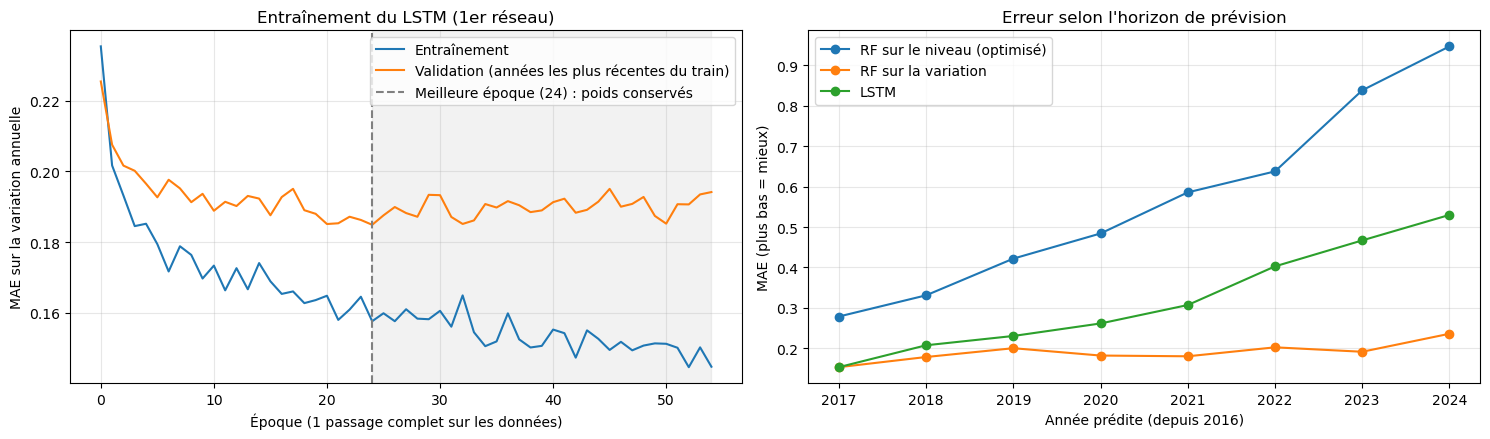

In [268]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

# 1) Courbe d'apprentissage du réseau : erreur à chaque passage sur les données (époque)
h = histories[0]
axes[0].plot(h['loss'], label="Entraînement")
axes[0].plot(h['val_loss'], label="Validation (années les plus récentes du train)")
best_epoch = int(np.argmin(h['val_loss']))   # époque gardée grâce à restore_best_weights=True
axes[0].axvline(best_epoch, color='grey', linestyle='--',
                label=f"Meilleure époque ({best_epoch}) : poids conservés")
axes[0].axvspan(best_epoch, len(h['loss']) - 1, color='grey', alpha=0.1)   # zone non utilisée (surapprentissage)
axes[0].set_xlabel("Époque (1 passage complet sur les données)")
axes[0].set_ylabel("MAE sur la variation annuelle")
axes[0].set_title("Entraînement du LSTM (1er réseau)")
axes[0].legend(); axes[0].grid(alpha=0.3)

# 2) Erreur selon l'horizon : RF optimisé (sur le niveau) vs RF sur la variation vs LSTM
err = pd.DataFrame({
    'year': test_keys['year'].values,
    'RF sur le niveau (optimisé)': np.abs(y_test.values - pred_best_rf),
    'RF sur la variation': np.abs(y_test.values - y_pred_rf_delta),
    'LSTM': np.abs(y_test.values - y_pred_lstm),
}).groupby('year').mean()
err.plot(marker='o', ax=axes[1])
axes[1].set_xlabel("Année prédite (depuis 2016)")
axes[1].set_ylabel("MAE (plus bas = mieux)")
axes[1].set_title("Erreur selon l'horizon de prévision")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Lecture :**
- **Courbe d'entraînement du LSTM** : l'erreur baisse à chaque époque ; l'entraînement s'arrête tout seul (*early stopping*) quand l'erreur de validation ne s'améliore plus pendant 30 époques, et on garde les meilleurs poids.
- **Le LSTM peut faire moins bien** : il y a en effet très peu de données pour un réseau de neurones.
- **Pistes d'essai** : modifier `configs` (L, units, dropout), prédire directement la variation depuis l'ancre comme le RF, ou ajouter d'autres variables du CSV.

## 10. Ajout des variables politiques

Je veux ajouter une nouvelle variable pour voir si ça améliore le modèle et répondre à la question : l'orientation politique du gouvernement (gauche / droite) ou le type de régime a-t-il un effet sur les émissions de CO₂ ?

**Construction de la variable** à partir de 3 sources complémentaires :
1. **ParlGov** : score gauche-droite (0 = gauche, 10 = droite) du parti du Premier ministre, pour 11 démocraties parlementaires ;
2. **Global Leader Ideology** : idéologie du chef de gouvernement (gauche / centre / droite) pour 10 autres démocraties ;
3. **V-Dem (via Our World in Data)** : type de régime, pour tous les pays, y compris les 9 régimes non démocratiques sans score gauche-droite.

On ajoute ensuite ces variables à notre **meilleur modèle, le RF sur la variation** pour voir si elles l'améliorent.

In [269]:
# CONSTRUCTION DE LA VARIABLE "ORIENTATION POLITIQUE" (ParlGov)
# ============================================================
# Repartir du dataset annuel d'origine (une ligne par pays/année)
df_annual = df.drop_duplicates(subset=['country','year'], keep='first')

# --- 1. Charger la table des cabinets ParlGov ---
df_cabinet = pd.read_csv("view_cabinet.csv")
df_cabinet['start_date'] = pd.to_datetime(df_cabinet['start_date'])

# On ne garde que le parti du Premier ministre = le "parti dominant" de chaque gouvernement
df_pm = df_cabinet[df_cabinet['prime_minister'] == 1].copy()
df_pm = df_pm.sort_values(['country_name', 'start_date'])
df_pm = df_pm.drop_duplicates(subset=['country_name', 'cabinet_id'], keep='first')

# --- 2. Construire le mapping pays/année ---
# Pour chaque année, on cherche quel gouvernement était en place au milieu de l'année (1er juillet)
# -> évite qu'un changement de gouvernement en fin d'année ne fausse artificiellement l'attribution
years = list(range(1990, 2025))
records = []

for country, group in df_pm.groupby('country_name'):
    group = group.sort_values('start_date').reset_index(drop=True)
    for year in years:
        cutoff = pd.Timestamp(f'{year}-07-01')
        valid = group[group['start_date'] <= cutoff]
        if len(valid) == 0:
            continue  # pas encore de gouvernement enregistré à cette date
        current_gov = valid.iloc[-1]
        records.append({
            'country': country,
            'year': year,
            'left_right': current_gov['left_right'],

        })

df_political = pd.DataFrame(records)

# --- 3. Fusionner avec le dataset climat ---
df_annual = df_annual.merge(
    df_political[['country', 'year', 'left_right']],
    on=['country', 'year'], how='left'
)

coverage = df_annual['left_right'].notna().mean() * 100
print(f"Couverture globale : {coverage:.1f}% des lignes ont un score politique")
print()
print("Pays couverts par ParlGov :")
print(df_annual.groupby('country')['left_right'].apply(lambda x: x.notna().mean()*100)
      .loc[lambda x: x > 0].index.tolist())


Couverture globale : 36.7% des lignes ont un score politique

Pays couverts par ParlGov :
['Australia', 'Canada', 'France', 'Germany', 'Japan', 'New Zealand', 'Norway', 'Poland', 'Sweden', 'Turkey', 'United Kingdom']


In [270]:
# COMPLÉTER AVEC UNE AUTRE SOURCE (Global Leader Ideology)
# POUR LES 10 DÉMOCRATIES NON COUVERTES PAR PARLGOV
# ============================================================
df_ideo = pd.read_csv("identifying_ideologues.tab", sep='\t')

# hog_ideology_num_full : 0=rightist, 1=leftist, 2=centrist, 3=none, 4=no information
# On ne garde que les vraies catégories idéologiques (0,1,2), le reste devient NaN
# Puis on convertit sur une échelle 0-10 comparable à ParlGov : gauche=2.5, centre=5, droite=7.5
mapping_scale = {0: 7.5, 1: 2.5, 2: 5.0}
df_ideo['left_right_alt'] = df_ideo['hog_ideology_num_full'].map(mapping_scale)

# Harmoniser le nom des USA avec le dataset climat
df_ideo['country_name'] = df_ideo['country_name'].replace({'United States of America': 'United States'})

# Les 10 démocraties non couvertes par ParlGov
democraties_manquantes = ['Argentina', 'Brazil', 'India', 'Indonesia', 'Kenya', 'Mexico',
                            'Nigeria', 'South Africa', 'South Korea', 'United States']

df_ideo_subset = df_ideo[df_ideo['country_name'].isin(democraties_manquantes)].copy()
df_ideo_subset = df_ideo_subset[['country_name','year','left_right_alt']].rename(columns={'country_name':'country'})
df_ideo_subset = df_ideo_subset[(df_ideo_subset['year']>=1990) & (df_ideo_subset['year']<=2024)]

# --- Fusionner avec df_annual, en complétant SEULEMENT les NaN de left_right existant ---
df_annual = df_annual.merge(df_ideo_subset, on=['country','year'], how='left')

# combine_first : garde left_right (ParlGov) quand il existe, sinon utilise left_right_alt
df_annual['left_right'] = df_annual['left_right'].combine_first(df_annual['left_right_alt'])
df_annual = df_annual.drop(columns=['left_right_alt'])


coverage = df_annual['left_right'].notna().mean() * 100
print(f"Nouvelle couverture globale : {coverage:.1f}%")
print()
print("Couverture par pays :")
print(df_annual.groupby('country')['left_right'].apply(lambda x: x.notna().mean()*100).sort_values(ascending=False))

Nouvelle couverture globale : 65.6%

Couverture par pays :
country
Australia         100.000000
United Kingdom    100.000000
Canada            100.000000
Turkey            100.000000
Sweden            100.000000
France            100.000000
Germany           100.000000
Poland            100.000000
Norway            100.000000
Japan             100.000000
New Zealand       100.000000
Argentina          88.571429
United States      88.571429
South Korea        88.571429
South Africa       88.571429
Mexico             88.571429
Kenya              88.571429
Indonesia          88.571429
India              88.571429
Brazil             88.571429
Nigeria            71.428571
Iran                0.000000
Pakistan            0.000000
Russia              0.000000
Saudi Arabia        0.000000
Ethiopia            0.000000
Egypt               0.000000
China               0.000000
Bangladesh          0.000000
Vietnam             0.000000
Name: left_right, dtype: float64


In [271]:
# COMPLÉTER LES RÉGIMES NON-DÉMOCRATIQUES AVEC V-DEM (regime_type)
# ============================================================
url = "https://ourworldindata.org/grapher/political-regime.csv?v=1&csvType=full&useColumnShortNames=false"
df_regime = pd.read_csv(url, storage_options={'User-Agent': 'Mozilla/5.0'})

# Renommer proprement
df_regime = df_regime.rename(columns={
    'Entity': 'country',
    'Year': 'year',
    'Political regime': 'regime_score'
})

# 0=Autocratie fermée, 1=Autocratie électorale, 2=Démocratie électorale, 3=Démocratie libérale
regime_labels = {0: 'Closed autocracy', 1: 'Electoral autocracy',
                 2: 'Electoral democracy', 3: 'Liberal democracy'}
df_regime['regime_type'] = df_regime['regime_score'].map(regime_labels)

df_regime = df_regime[['country','year','regime_type']]

# --- Vérifier les noms de pays avant de fusionner ---
pays_climat = set(df_annual['country'].unique())
pays_vdem = set(df_regime['country'].unique())
print("Pays climat non trouvés dans V-Dem :", pays_climat - pays_vdem)

# --- Fusionner avec df_annual ---
df_annual = df_annual.merge(df_regime, on=['country','year'], how='left')

print(f"\nCouverture regime_type : {df_annual['regime_type'].notna().mean()*100:.1f}%")
print(df_annual.groupby('country')['regime_type'].first())

Pays climat non trouvés dans V-Dem : set()

Couverture regime_type : 99.8%
country
Argentina         Electoral democracy
Australia           Liberal democracy
Bangladesh        Electoral autocracy
Brazil            Electoral democracy
Canada              Liberal democracy
China                Closed autocracy
Egypt             Electoral autocracy
Ethiopia             Closed autocracy
France              Liberal democracy
Germany             Liberal democracy
India             Electoral democracy
Indonesia         Electoral autocracy
Iran              Electoral autocracy
Japan               Liberal democracy
Kenya             Electoral autocracy
Mexico            Electoral autocracy
New Zealand         Liberal democracy
Nigeria              Closed autocracy
Norway              Liberal democracy
Pakistan          Electoral autocracy
Poland            Electoral democracy
Russia               Closed autocracy
Saudi Arabia         Closed autocracy
South Africa         Closed autocracy
South

**Visualisation**

In [276]:
from scipy.stats import pearsonr

annual_unique = df_annual.drop_duplicates(['country', 'year'])
# Indicateur « vrai score politique disponible » (left_right n'est pas encore imputé à ce stade).
# Si la cellule de préparation du modèle a déjà tourné, la colonne existe déjà : on la garde.
if 'has_left_right' not in annual_unique.columns:
    annual_unique['has_left_right'] = annual_unique['left_right'].notna().astype(int)

def yearly_trend(g, col):
    """Pente moyenne par an (régression linéaire de la variable sur l'année)."""
    return np.polyfit(g['year'], g[col], 1)[0] if g[col].notna().sum() >= 5 else np.nan

def summarize_countries(rows):
    """Moyennes par pays + évolutions annuelles moyennes (CO2 en %/an, renouvelables en points/an)."""
    out = rows.groupby('country').agg(
        nb_annees=('year', 'nunique'),
        co2_per_capita=('co2_per_capita', 'mean'),
        gdp_per_capita_usd=('gdp_per_capita_usd', 'mean'),
        share_renewables_pct=('share_renewables_pct', 'mean'),
        share_coal_pct=('share_coal_pct', 'mean'),
    )
    for country, g in rows.groupby('country'):
        out.loc[country, 'evol_co2_pct_an'] = 100 * yearly_trend(g, 'co2_per_capita') / g['co2_per_capita'].mean()
        out.loc[country, 'evol_renouv_pts_an'] = yearly_trend(g, 'share_renewables_pct')
    return out

# --- Démocraties : moyennes sur les années avec un vrai score politique ---
pol_real = annual_unique[annual_unique['has_left_right'] == 1]
country_pol = summarize_countries(pol_real)
country_pol.insert(0, 'left_right_moyen', pol_real.groupby('country')['left_right'].mean())
# Source du score : ParlGov (échelle continue) ou Global Leader Ideology (3 catégories)
country_pol['source'] = np.where(country_pol.index.isin(democraties_manquantes),
                                 'Global Leader Ideology', 'ParlGov')
country_pol = country_pol.sort_values('left_right_moyen')

# --- Autocraties : pays sans AUCUN score gauche-droite, moyennes sur toutes les années ---
no_score = annual_unique.groupby('country')['has_left_right'].max()
aut_rows = annual_unique[annual_unique['country'].isin(no_score[no_score == 0].index)]
country_aut = summarize_countries(aut_rows)
country_aut['regime_majoritaire'] = aut_rows.groupby('country')['regime_type'].agg(lambda x: x.mode()[0])

print(f"{len(country_pol)} pays avec un vrai score politique | {len(country_aut)} autocraties sans score")

21 pays avec un vrai score politique | 9 autocraties sans score


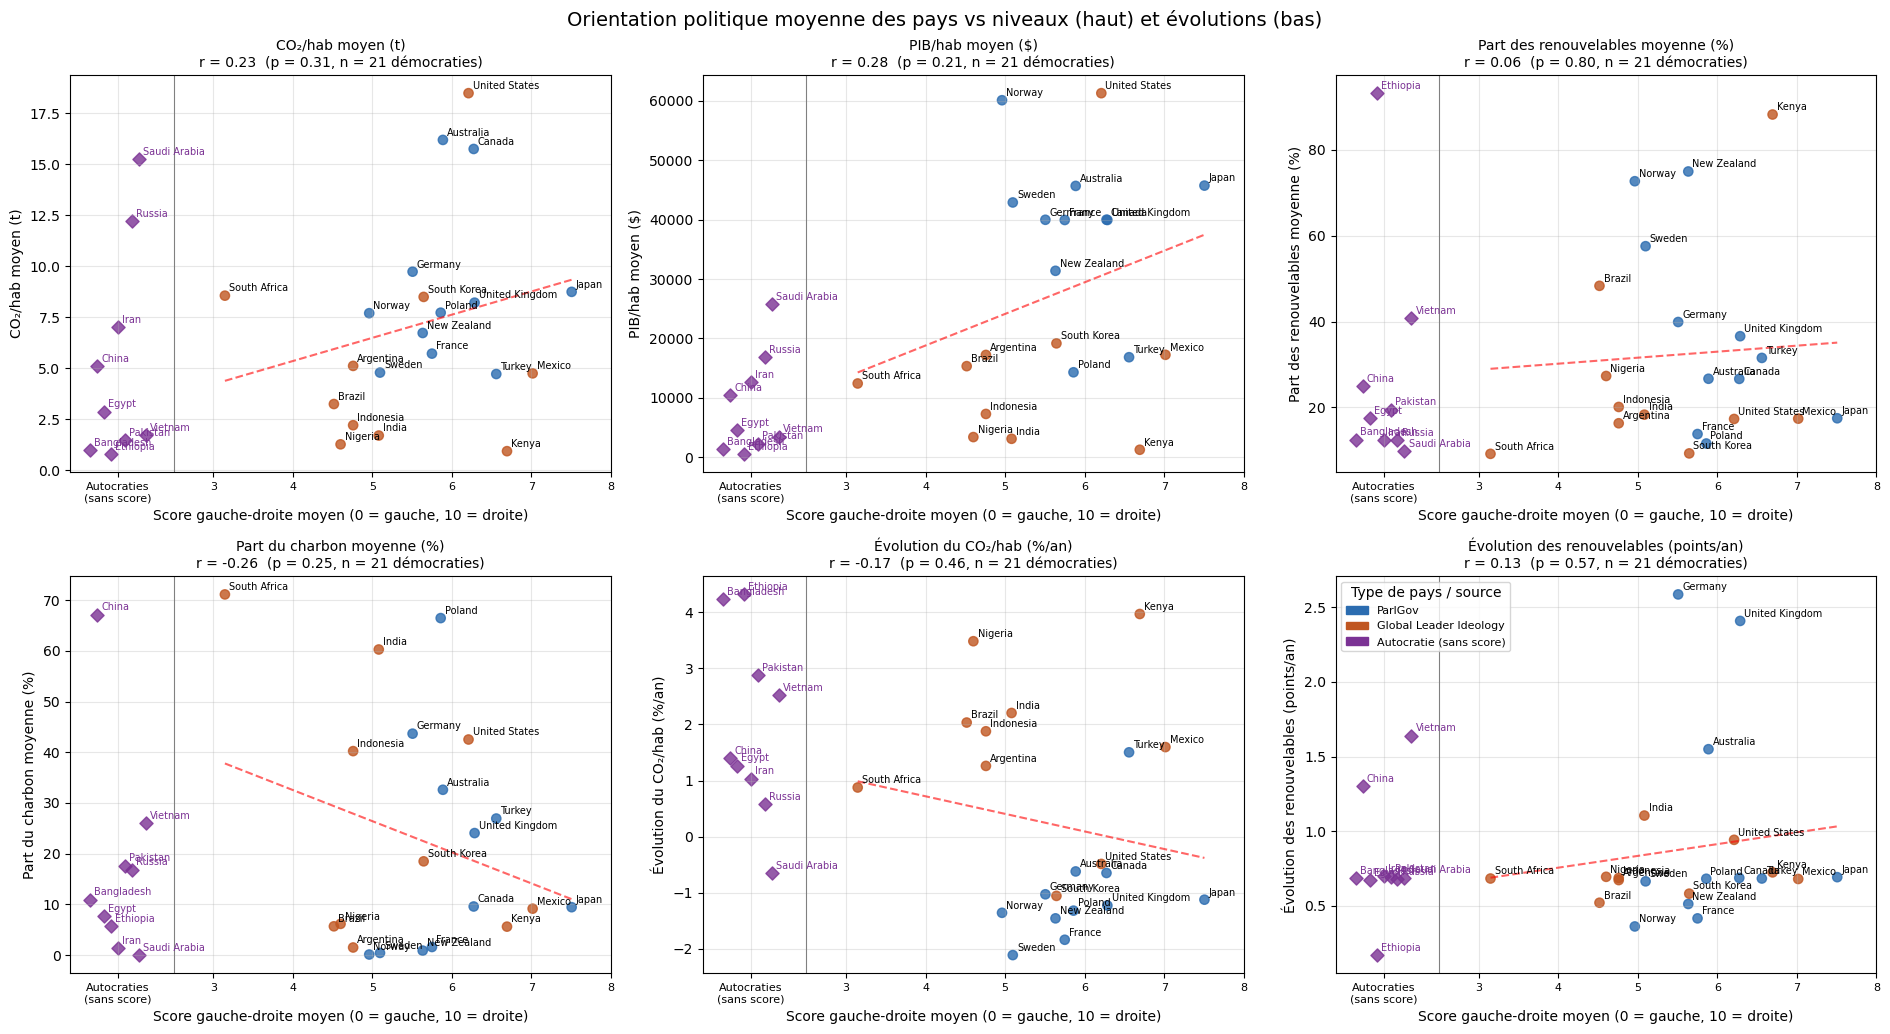

In [ ]:
# --- 2 et 3. Orientation moyenne vs autres variables (une ligne = niveaux, une ligne = évolutions) ---
# Les autocraties n'ont pas de score gauche-droite : elles sont placées dans une colonne à part (à gauche),
# et ne sont PAS prises en compte dans la droite de régression ni dans r.
colors = {'ParlGov': '#2b6cb0', 'Global Leader Ideology': '#c05621', 'Autocratie (sans score)': '#7b3294'}
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in colors.values()]
X_AUT = 1.8                                                   # position de la colonne « autocraties »
x_aut = X_AUT + np.linspace(-0.35, 0.35, len(country_aut))    # léger étalement pour lire les noms

panels = [
    ('co2_per_capita', "CO₂/hab moyen (t)"),
    ('gdp_per_capita_usd', "PIB/hab moyen ($)"),
    ('share_renewables_pct', "Part des renouvelables moyenne (%)"),
    ('share_coal_pct', "Part du charbon moyenne (%)"),
    ('evol_co2_pct_an', "Évolution du CO₂/hab (%/an)"),
    ('evol_renouv_pts_an', "Évolution des renouvelables (points/an)"),
]

fig, axes = plt.subplots(2, 3, figsize=(19, 10.5))
for ax, (col, label) in zip(axes.flatten(), panels):
    # Démocraties (avec score)
    d = country_pol[['left_right_moyen', col, 'source']].dropna()
    ax.scatter(d['left_right_moyen'], d[col], c=d['source'].map(colors), s=45, alpha=0.8)
    for country, row in d.iterrows():
        ax.annotate(country, (row['left_right_moyen'], row[col]), fontsize=7,
                    xytext=(3, 3), textcoords='offset points')

    # Autocraties (sans score), colonne à part
    ax.scatter(x_aut, country_aut[col], color=colors['Autocratie (sans score)'], s=45, alpha=0.8, marker='D')
    for x, (country, val) in zip(x_aut, country_aut[col].items()):
        ax.annotate(country, (x, val), fontsize=7, xytext=(3, 3), textcoords='offset points',
                    color=colors['Autocratie (sans score)'])
    ax.axvline(2.5, color='grey', linewidth=0.8)

    # Droite de régression + corrélation de Pearson (démocraties uniquement)
    slope, intercept = np.polyfit(d['left_right_moyen'], d[col], 1)
    xs = np.linspace(d['left_right_moyen'].min(), d['left_right_moyen'].max(), 50)
    ax.plot(xs, slope * xs + intercept, 'r--', alpha=0.6)
    r, p = pearsonr(d['left_right_moyen'], d[col])
    ax.set_title(f"{label}\nr = {r:.2f}  (p = {p:.2f}, n = {len(d)} démocraties)", fontsize=10)

    ax.set_xlim(1.2, 8)
    ax.set_xticks([X_AUT, 3, 4, 5, 6, 7, 8])
    ax.set_xticklabels(['Autocraties\n(sans score)', '3', '4', '5', '6', '7', '8'], fontsize=8)
    ax.set_xlabel("Score gauche-droite moyen (0 = gauche, 10 = droite)")
    ax.set_ylabel(label)
    ax.grid(alpha=0.3)

axes[1, 2].legend(handles, colors.keys(), title="Type de pays / source", fontsize=8)
fig.suptitle("Orientation politique moyenne des pays vs niveaux (haut) et évolutions (bas)", fontsize=14)
plt.tight_layout()
plt.show()

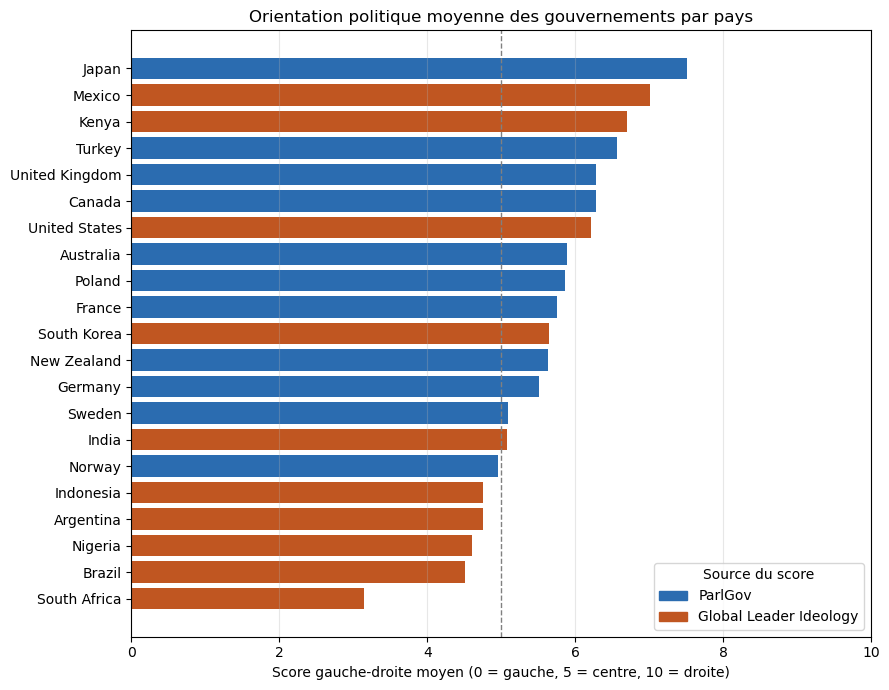

In [ ]:
# --- 1. Classement des pays selon leur orientation moyenne ---
colors = {'ParlGov': '#2b6cb0', 'Global Leader Ideology': '#c05621'}
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(country_pol.index, country_pol['left_right_moyen'],
        color=country_pol['source'].map(colors))
ax.axvline(5, color='grey', linestyle='--', linewidth=1)
ax.set_xlim(0, 10)
ax.set_xlabel("Score gauche-droite moyen (0 = gauche, 5 = centre, 10 = droite)")
ax.set_title("Orientation politique moyenne des gouvernements par pays")
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in colors.values()]
ax.legend(handles, colors.keys(), title="Source du score", loc='lower right')
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

### RF sur la variation + variables politiques

On reprend le **RF sur la variation depuis la dernière année connue** (section 8) et on lui ajoute :
- `left_right` à l'année prédite et **son évolution depuis l'ancre** `d_left_right` (le pays a-t-il basculé à gauche ou à droite depuis l'ancre ?) ;
- `has_left_right` (score réel disponible ou valeur imputée à 5) ;
- `regime_type` (type de régime V-Dem) en variables indicatrices.

Même protocole qu'en section 8 : comparaison **sans / avec** variables politiques sur la validation (ancre 2012 → 2013-2016), puis test 2017-2024 une seule fois, puis importance par permutation.

In [273]:
# PRÉPARATION DES VARIABLES POLITIQUES POUR LE MODÈLE
# ============================================================
# --- 1. Indicateur : a-t-on un vrai score left_right pour cette ligne ? ---
# Permet au modèle de distinguer "pas de score (régime non démocratique)" d'une vraie valeur centriste (5.0)
df_annual['has_left_right'] = df_annual['left_right'].notna().astype(int)

# --- 2. Imputer les NaN de left_right avec une valeur neutre (5.0 = centre) ---
# Le Random Forest de sklearn n'accepte pas les NaN ; combiné à has_left_right,
# le modèle peut traiter différemment "vraiment centriste" et "information manquante"
df_annual['left_right'] = df_annual['left_right'].fillna(5.0)

# --- 3. regime_type : combler les ~0.2% de NaN restants avec une catégorie dédiée ---
df_annual['regime_type'] = df_annual['regime_type'].fillna('Unknown')

In [274]:
# --- Base : données de df_model (mêmes lignes que le RF sur la variation) + variables politiques ---
pol_cols = ['left_right', 'has_left_right', 'regime_type']
base_pol = df_model[['country', 'year', target] + delta_cols].merge(
    df_annual[['country', 'year'] + pol_cols].drop_duplicates(['country', 'year']),
    on=['country', 'year'], how='left')

regime_dummies = pd.get_dummies(base_pol['regime_type'], prefix='regime', dtype=int)
regime_cols = list(regime_dummies.columns)
base_pol = pd.concat([base_pol, regime_dummies], axis=1)
print("Valeurs manquantes :", base_pol[pol_cols].isna().sum().to_dict())
print("Types de régime :", regime_cols)

def make_pairs_pol(anchor_years, target_min, target_max, hmax=8):
    """Même construction que make_pairs, en ajoutant les variables politiques."""
    num = delta_cols + ['left_right']                      # variables dont on calcule l'évolution depuis l'ancre
    b = base_pol[base_pol['year'].isin(anchor_years)][['country', 'year', target] + num]
    t = base_pol[(base_pol['year'] >= target_min) & (base_pol['year'] <= target_max)]
    p = t.merge(b, on='country', suffixes=('', '_b'))
    p['h'] = p['year'] - p['year_b']
    p = p[(p['h'] >= 1) & (p['h'] <= hmax)].copy()
    for f in num:
        p['d_' + f] = p[f] - p[f + '_b']
    p['delta'] = p[target] - p[target + '_b']
    return p

political_features = ['left_right', 'd_left_right', 'has_left_right'] + regime_cols
feature_sets = {
    'RF variation (sans politique)': delta_features,
    'RF variation + politique': delta_features + political_features,
}

# --- Validation : ancre 2012 -> 2013-2016 ---
pp_fit = make_pairs_pol(range(1995, 2012), 1995, 2012)
pp_val = make_pairs_pol([2012], 2013, 2016)
print("\nMAE validation 2013-2016 :")
for name, feats in feature_sets.items():
    m = RandomForestRegressor(n_estimators=300, min_samples_leaf=5, random_state=42, n_jobs=-1)
    m.fit(pp_fit[feats], pp_fit['delta'])
    print(f"  {name:32s} {mean_absolute_error(pp_val[target], pp_val[target + '_b'] + m.predict(pp_val[feats])):.3f}")

Valeurs manquantes : {'left_right': 0, 'has_left_right': 0, 'regime_type': 0}
Types de régime : ['regime_Closed autocracy', 'regime_Electoral autocracy', 'regime_Electoral democracy', 'regime_Liberal democracy', 'regime_Unknown']

MAE validation 2013-2016 :
  RF variation (sans politique)    0.195
  RF variation + politique         0.196


In [275]:
# --- Test 2017-2024 depuis l'ancre 2016 (une seule fois) ---
pp_train = make_pairs_pol(range(1995, 2016), 1995, 2016)
pp_test = make_pairs_pol([2016], 2017, 2024)

rf_pol_models, results_pol = {}, []
for name, feats in feature_sets.items():
    m = RandomForestRegressor(n_estimators=300, min_samples_leaf=5, random_state=42, n_jobs=-1)
    m.fit(pp_train[feats], pp_train['delta'])
    pp_test['pred'] = pp_test[target + '_b'] + m.predict(pp_test[feats])
    y_pred = test_keys.merge(pp_test[['country', 'year', 'pred']], on=['country', 'year'], how='left')['pred'].values
    results_pol.append(modelresults(y_pred, name))
    rf_pol_models[name] = m

rf_delta_pol = rf_pol_models['RF variation + politique']
results_rf_delta_pol = results_pol[1]
pd.DataFrame(results_pol)

Results for RF variation (sans politique):
Mean absolute error on model is 0.1905
Mean squared error on model is 0.0602
The r2 score on model is 0.9966
Results for RF variation + politique:
Mean absolute error on model is 0.1878
Mean squared error on model is 0.0586
The r2 score on model is 0.9967


,Model,MAE,MSE,R2 Score
0,RF variation (sans politique),0.190500,0.060150,0.996625
1,RF variation + politique,0.187772,0.058596,0.996713


In [277]:
# --- Importance par permutation (test) : les variables politiques aident-elles ? ---
rng = np.random.default_rng(42)
feats_pol = feature_sets['RF variation + politique']

def pol_test_mae(P):
    return mean_absolute_error(P[target], P[target + '_b'] + rf_delta_pol.predict(P[feats_pol]))

base_mae_pol = pol_test_mae(pp_test)
groups = {
    'Orientation gauche-droite (left_right, d_left_right, has_left_right)': ['left_right', 'd_left_right', 'has_left_right'],
    'Type de régime (regime_type)': regime_cols,
    'PIB/hab (niveau + évolution)': ['gdp_per_capita_usd', 'd_gdp_per_capita_usd'],
    'Motorisation (niveau + évolution)': ['vehicle_ownership', 'd_vehicle_ownership'],
}
rows = []
for name, cols in groups.items():
    inc = []
    for _ in range(10):
        P = pp_test.copy()
        P[cols] = pp_test[cols].values[rng.permutation(len(pp_test))]
        inc.append(pol_test_mae(P) - base_mae_pol)
    rows.append({'groupe de variables': name, 'hausse de la MAE si mélangé': np.mean(inc), 'écart-type': np.std(inc)})

print(f"MAE test du modèle avec politique : {base_mae_pol:.3f}")
pd.DataFrame(rows).sort_values('hausse de la MAE si mélangé', ascending=False).round(4)

MAE test du modèle avec politique : 0.188


,groupe de variables,hausse de la MAE si mélangé,écart-type
3,Motorisation (niveau + évolution),0.2172,0.0240
2,PIB/hab (niveau + évolution),0.0886,0.0065
0,"Orientation gauche-droite (left_right, d_left_...",0.0050,0.0022
1,Type de régime (regime_type),0.0018,0.0014


**Conclusion : les variables politiques n'améliorent pas le modèle.**
- **Validation (2013-2016)** : la MAE est identique, 0,195 sans et 0,196 avec les variables politiques.
- **Test (2017-2024)** : 0,191 sans, 0,188 avec. Le gain de 0,003 t/hab est négligeable et n'apparaissait pas en validation, c'est du bruit.
- **Importance par permutation** : mélanger au hasard l'orientation gauche-droite n'augmente la MAE que de 0,005, et le type de régime de 0,002. À comparer avec la motorisation (+0,217) et le PIB/hab (+0,089).

Une fois connues l'évolution du PIB, de la motorisation et du mix énergétique, la couleur politique du gouvernement n'apporte presque aucune information supplémentaire sur l'évolution des émissions. La comparaison descriptive ci-dessous aide à comprendre pourquoi.